Import Libraries

In [ ]:
!pip install scikit-learn-extra

In [ ]:
#Data manipulation
import numpy as np
import pandas as pd

#Data presentation/visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#File Import
from google.colab import files
import io

#Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from statsmodels.stats.proportion import proportions_ztest

#Data Split
from sklearn.model_selection import train_test_split, StratifiedKFold

#Decision Trees
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

#Model Stats
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score
from imblearn.metrics import geometric_mean_score

#Unsupervised learning
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# K-medoids is not included in standard scikit-learn.
from sklearn_extra.cluster import KMedoids

print("Libraries loaded.")

Libraries loaded.


# Task 1
**Data preprocessing and exploratory analysis**


Read Dataset
Link: https://www.kaggle.com/datasets/zeyadmohamed26/netflix-customer-churn-and-engagement-analytics?resource=download&select=netflix_customer_churn.csv

# Attributes for netflix_customer_churn.csv dataset:
1 customer_id - unique anonymous subscriber identifier (string: UUID format)

2 age - customer age in completed years (numeric: from 18 to 70)

3 gender - customer demographic self-identification (nominal: 'Female', 'Male', or 'Other')

4 subscription_type - current Netflix subscription tier (nominal: 'Basic', 'Standard', or 'Premium')

5 watch_hours - total cumulative monthly streaming hours (numeric: from 0.10 to 110.40)

6 last_login_days - number of days elapsed since the subscriber last logged in (numeric: from 0 to 60)

7 region - primary geographic operational market (nominal: 'Africa', 'Asia', 'Europe', 'North America', 'Oceania', or 'South America')

8 device - primary viewing hardware platform (nominal: 'Desktop', 'Laptop', 'Mobile', 'TV', or 'Tablet')

9 monthly_fee - regular monthly recurring fee billed to account in USD (numeric: 8.99, 13.99, or 17.99)

10 churned - whether subscriber cancelled service (binary: 0 - active or 1 - churned, output target)

11 payment_method - payment method registered on the billing profile (nominal: 'Credit Card', 'Crypto', 'Debit Card', 'Gift Card', or 'PayPal')

12 number_of_profiles - active viewer sub-profiles on account (numeric: from 1 to 5)

13 avg_watch_time_per_day - calculated daily streaming engagement average in hours (numeric: from 0.01 to 4.97)

14 favorite_genre - most frequently streamed content genre (nominal: 'Action', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', or 'Thriller')

---------------------------------------------------------------

#***TO RUN THE CODE: DATASET (.csv) SHOULD BE UPLOADED TO COLAB***

Read the dataset

In [ ]:
uploaded = files.upload()

df = pd.read_csv("netflix_customer_churn.csv")

# Display the first five observations
display(df.head())

# Dataset dimensions
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

# Variable names and data types
print("--------------------------")
print("\nVariable information:")
df.info()

Saving netflix_customer_churn.csv to netflix_customer_churn (2).csv


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


Dataset shape: (5000, 14)
Number of observations: 5000
Number of variables: 14
--------------------------

Variable information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_pe

Drop *IDs* and *avg_watch_time_per_day* and *monthly_fee* as a redundant

In [ ]:
df =df.drop(columns=['customer_id'])
df =df.drop(columns=['avg_watch_time_per_day'])
df =df.drop(columns=['monthly_fee'])
display(df.head())
# Dataset dimensions
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

,age,gender,subscription_type,watch_hours,last_login_days,region,device,churned,payment_method,number_of_profiles,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,1,Gift Card,1,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,1,Gift Card,5,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,0,Crypto,2,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,1,Crypto,2,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,1,Crypto,2,Action


Dataset shape: (5000, 11)
Number of observations: 5000
Number of variables: 11



Check for Missing Values

In [ ]:
missing_values_null = pd.DataFrame({
    "Missing values": df.isnull().sum(),
    "Missing percentage (%)": df.isnull().mean() * 100
})

missing_values_nan = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage (%)": df.isna().mean() * 100
})

print("NULL VALUES:")
display(missing_values_null)

print("\n\nNAN VALUES:")
display(missing_values_nan)

NULL VALUES:


,Missing values,Missing percentage (%)
age,0,0.0
gender,0,0.0
subscription_type,0,0.0
watch_hours,0,0.0
last_login_days,0,0.0
region,0,0.0
device,0,0.0
churned,0,0.0
payment_method,0,0.0
number_of_profiles,0,0.0




NAN VALUES:


,Missing values,Missing percentage (%)
age,0,0.0
gender,0,0.0
subscription_type,0,0.0
watch_hours,0,0.0
last_login_days,0,0.0
region,0,0.0
device,0,0.0
churned,0,0.0
payment_method,0,0.0
number_of_profiles,0,0.0


Delete Rows with Missing Values

In [ ]:
#print("\nDrop columns with at least 1 NaN:\n", df.dropna(axis=1))
#print("\nDrop rows where all values are NaN:\n", df.dropna(how='all'))
print("\nDrop rows with at least 1 NaN/NULL:\n", df.dropna())



Drop rows with at least 1 NaN/NULL:
       age  gender subscription_type  watch_hours  last_login_days  \
0      51   Other             Basic        14.73               29   
1      47   Other          Standard         0.70               19   
2      27  Female          Standard        16.32               10   
3      53   Other           Premium         4.51               12   
4      56   Other          Standard         1.89               13   
...   ...     ...               ...          ...              ...   
4995   19  Female             Basic        49.17               11   
4996   67  Female             Basic         9.24                2   
4997   66    Male          Standard        16.55               49   
4998   59  Female             Basic         9.12                3   
4999   57    Male             Basic         1.62               17   

             region   device  churned payment_method  number_of_profiles  \
0            Africa       TV        1      Gift Card     

Check for Written Errors in Dataset

In [ ]:
for col in df.columns:
    print(df[col].value_counts())
    print("-"*30)

age
63    111
24    110
18    108
22    108
59    108
62    107
46    105
36    105
29    104
54    104
31    103
58    103
66     99
23     99
26     99
51     98
57     98
20     98
49     97
56     97
33     97
44     97
64     96
38     96
35     96
28     96
37     96
69     95
40     95
47     95
65     94
25     94
70     93
21     92
68     92
34     92
32     92
19     92
67     89
55     89
30     88
50     87
39     87
48     85
61     85
41     84
60     84
53     84
27     82
45     76
52     75
42     72
43     72
Name: count, dtype: int64
------------------------------
gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64
------------------------------
subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64
------------------------------
watch_hours
0.24     11
0.12     10
4.69      9
4.12      9
3.05      9
         ..
13.32     1
7.87      1
33.71     1
23.24     1
8.76      1
Name: count, Length: 2343, dty

Check for Duplicates


In [ ]:
print(df.duplicated(keep='last'))
print("\nTotal number of duplicates:",df.duplicated().sum())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

Total number of duplicates: 0


Delete Duplicates

In [ ]:
initial_len = len(df)
print("\nInitial length:",initial_len)
df = df.drop_duplicates()
print("\n#Cleaning from Duplicates")
final_len = len(df)
print("\nFinal length after duplicates deletion:",final_len)


Initial length: 5000

#Cleaning from Duplicates

Final length after duplicates deletion: 5000


Standartize text inputs (to lower-case string-based feature entries)

In [ ]:
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()
display(df.head())

,age,gender,subscription_type,watch_hours,last_login_days,region,device,churned,payment_method,number_of_profiles,favorite_genre
0,51,other,basic,14.73,29,africa,tv,1,gift card,1,action
1,47,other,standard,0.70,19,europe,mobile,1,gift card,5,sci-fi
2,27,female,standard,16.32,10,asia,tv,0,crypto,2,drama
3,53,other,premium,4.51,12,oceania,tv,1,crypto,2,horror
4,56,other,standard,1.89,13,africa,mobile,1,crypto,2,action


Dataset Description

Descriptive statistics for numerical variables

In [ ]:
print(df.columns.tolist())

numeric_columns = [
    "age",
    "watch_hours",
    "last_login_days",
    "number_of_profiles"
]

numeric_statistics = df[numeric_columns].describe().T

descriptive_statistics = []
for column in numeric_columns:
    # Coerce to numeric and drop missing values
    data = pd.to_numeric(df[column], errors="coerce").dropna()

    # Skip if column is empty after dropping NaNs
    if data.empty:
        continue

    # Calculate Mode cleanly
    mode_values = data.mode()
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    elif len(mode_values) > 1:
        mode = ", ".join([f"{val:.4f}" if isinstance(val, (float, np.floating)) else str(val) for val in mode_values])
    else:
        mode = np.nan

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and Maximum
    minimum = data.min()
    maximum = data.max()

    # Range and IQR
    data_range = maximum - minimum
    iqr = q3 - q1

    descriptive_statistics.append({
        "Variable": column,
        "Count": len(data),
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Convert list of dicts to DataFrame
descriptive_statistics_df = pd.DataFrame(descriptive_statistics)

# Round numeric output columns for clean display
numeric_stat_cols = descriptive_statistics_df.select_dtypes(include=[np.number]).columns
descriptive_statistics_df[numeric_stat_cols] = descriptive_statistics_df[numeric_stat_cols].round(3)

display(descriptive_statistics_df)

['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'churned', 'payment_method', 'number_of_profiles', 'favorite_genre']


,Variable,Count,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,5000,43.847,44.0,63.00,18.00,30.000,44.0,58.00,70.0,52.00,28.000,240.285,15.501,0.006,-1.244
1,watch_hours,5000,11.649,8.0,0.24,0.01,3.338,8.0,16.03,110.4,110.39,12.692,144.352,12.015,2.259,7.797
2,last_login_days,5000,30.090,30.0,37.00,0.00,15.000,30.0,45.00,60.0,60.00,30.000,307.514,17.536,-0.026,-1.190
3,number_of_profiles,5000,3.024,3.0,5.00,1.00,2.000,3.0,4.00,5.0,4.00,2.000,2.005,1.416,-0.017,-1.303


Frequency tables for categorical variables

In [ ]:
categorical_columns = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table)


gender


,Frequency,Percentage (%)
gender,,
female,1711,34.22
male,1654,33.08
other,1635,32.70



subscription_type


,Frequency,Percentage (%)
subscription_type,,
premium,1693,33.86
basic,1661,33.22
standard,1646,32.92



region


...

,Frequency,Percentage (%)
device,,
tablet,1048,20.96
laptop,1006,20.12
mobile,1004,20.08
tv,993,19.86
desktop,949,18.98



payment_method


,Frequency,Percentage (%)
payment_method,,
debit card,1030,20.60
paypal,1026,20.52
crypto,995,19.90
gift card,976,19.52
credit card,973,19.46



favorite_genre


,Frequency,Percentage (%)
favorite_genre,,
drama,731,14.62
documentary,729,14.58
romance,725,14.50
sci-fi,720,14.40
horror,713,14.26
action,697,13.94
comedy,685,13.70


Cross tabulations (Crosstabs)

Random

In [ ]:
crosstab_pairs = [(col, "churned") for col in categorical_columns if col != "churned"]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        df[row_variable],
        df[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        df[row_variable],
        df[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): gender × churned


churned,0,1
gender,,
female,837,874
male,827,827
other,821,814



Crosstab (total percentages): gender × churned


churned,0,1
gender,,
female,16.74,17.48
male,16.54,16.54
other,16.42,16.28



Crosstab (frequencies): subscription_type × churned


...

churned,0,1
payment_method,,
credit card,10.98,8.48
crypto,8.02,11.88
debit card,11.60,9.00
gift card,8.24,11.28
paypal,10.86,9.66



Crosstab (frequencies): favorite_genre × churned


churned,0,1
favorite_genre,,
action,332,365
comedy,343,342
documentary,359,370
drama,349,382
horror,346,367
romance,375,350
sci-fi,381,339



Crosstab (total percentages): favorite_genre × churned


churned,0,1
favorite_genre,,
action,6.64,7.30
comedy,6.86,6.84
documentary,7.18,7.40
drama,6.98,7.64
horror,6.92,7.34
romance,7.50,7.00
sci-fi,7.62,6.78


---------------------------------------------------------------

z-scores

In [ ]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        df[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=df.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,watch_hours,last_login_days,number_of_profiles
0,0.461471,0.256425,-0.062152,-1.429965
1,0.203399,-0.911432,-0.632462,1.395494
2,-1.086959,0.388777,-1.145741,-0.723600
3,0.590506,-0.594288,-1.031679,-0.723600
4,0.784060,-0.812377,-0.974648,-0.723600


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,-0.0,1.0001,-1.6676,1.6873
1,watch_hours,0.0,1.0001,-0.9689,8.2200
2,last_login_days,-0.0,1.0001,-1.7161,1.7058
3,number_of_profiles,0.0,1.0001,-1.4300,1.3955


Detecting outliers using z-scores

In [ ]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(df) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            [ column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,0,0.00
1,watch_hours,102,2.04
2,last_login_days,0,0.00
3,number_of_profiles,0,0.00



age: No observations with |z| > 3.

z-score outliers: watch_hours


,watch_hours,z-score
623,47.74,3.004178
2027,47.74,3.004178
2998,47.76,3.005843
244,47.79,3.008340
3060,47.81,3.010005
...,...,...
3656,89.83,6.507751
339,92.07,6.694208
2017,98.42,7.222782
4544,101.06,7.442536



last_login_days: No observations with |z| > 3.

number_of_profiles: No observations with |z| > 3.


Detecting outliers using the IQR method

In [ ]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            [column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,30.0000,58.00,28.0000,-54.00,142.0000,0,0.00
1,watch_hours,3.3375,16.03,12.6925,-34.74,54.1075,57,1.14
2,last_login_days,15.0000,45.00,30.0000,-75.00,135.0000,0,0.00
3,number_of_profiles,2.0000,4.00,2.0000,-4.00,10.0000,0,0.00



age: No IQR outliers detected.

IQR outliers: watch_hours


,watch_hours
3557,54.34
3025,54.48
4285,54.53
1126,54.56
634,54.65
847,54.86
4689,54.98
2932,55.13
4960,55.15
524,55.55



last_login_days: No IQR outliers detected.

number_of_profiles: No IQR outliers detected.


Compare the two outlier-detection methods

In [ ]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,0,0,0
1,watch_hours,102,57,45
2,last_login_days,0,0,0
3,number_of_profiles,0,0,0


Box-and-whisker diagram (boxplot)

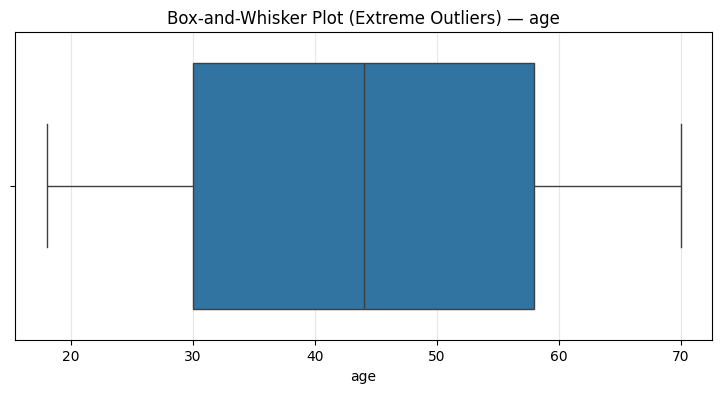

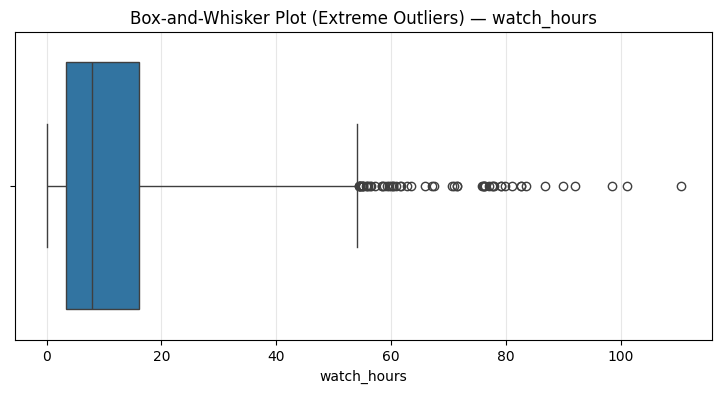

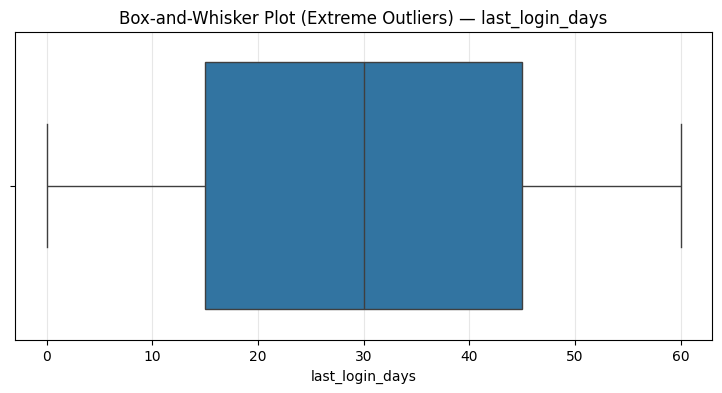

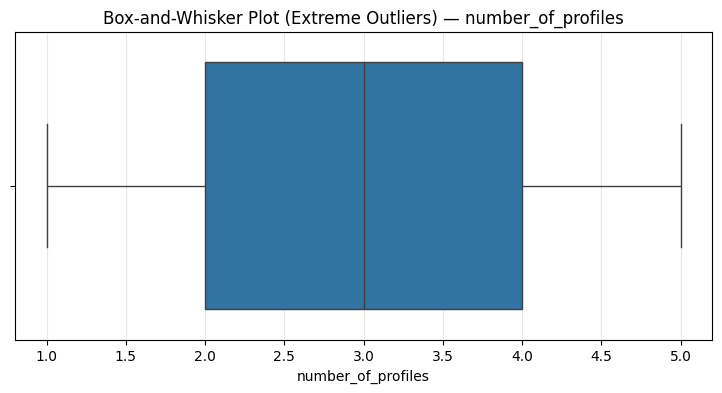

In [ ]:
for column in numeric_columns:
    plt.figure(figsize=(9, 4))

    # Setting whis=3.0 flags only extreme outliers (> 3 * IQR)
    sns.boxplot(
        data=df,
        x=column,
        whis=3.0
    )

    plt.title(f"Box-and-Whisker Plot (Extreme Outliers) — {column}")
    plt.xlabel(column)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

Outliers handling

*Recalculation of outliers : capping 'watch_hours' to end of quartile.*

In [ ]:
# Clip watch_hours at the 99th percentile threshold
upper_threshold = df['watch_hours'].quantile(0.99)
df['watch_hours'] = np.clip(df['watch_hours'], a_min=None, a_max=upper_threshold)

# Re-verify summary statistics after cleaning
print(f"Capped upper limit for watch_hours: {upper_threshold:.2f} hrs")
display(df[['watch_hours']].describe())

Capped upper limit for watch_hours: 54.98 hrs


,watch_hours
count,5000.000000
mean,11.488277
std,11.226075
min,0.010000
25%,3.337500
50%,8.000000
75%,16.030000
max,54.981500


Detecting Outliers once-again

In [ ]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            [column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,30.0000,58.00,28.0000,-54.00,142.0000,0,0.00
1,watch_hours,3.3375,16.03,12.6925,-34.74,54.1075,57,1.14
2,last_login_days,15.0000,45.00,30.0000,-75.00,135.0000,0,0.00
3,number_of_profiles,2.0000,4.00,2.0000,-4.00,10.0000,0,0.00



age: No IQR outliers detected.

IQR outliers: watch_hours


,watch_hours
3557,54.3400
3025,54.4800
4285,54.5300
1126,54.5600
634,54.6500
847,54.8600
4689,54.9800
76,54.9815
524,54.9815
451,54.9815



last_login_days: No IQR outliers detected.

number_of_profiles: No IQR outliers detected.


Display the number of outliers

In [ ]:
outlier_counts_df = iqr_summary[["Variable", "Potential outliers", "Percentage (%)"]]
print(outlier_counts_df)

             Variable  Potential outliers  Percentage (%)
0                 age                   0            0.00
1         watch_hours                  57            1.14
2     last_login_days                   0            0.00
3  number_of_profiles                   0            0.00


Box-and-whisker diagram (boxplot)

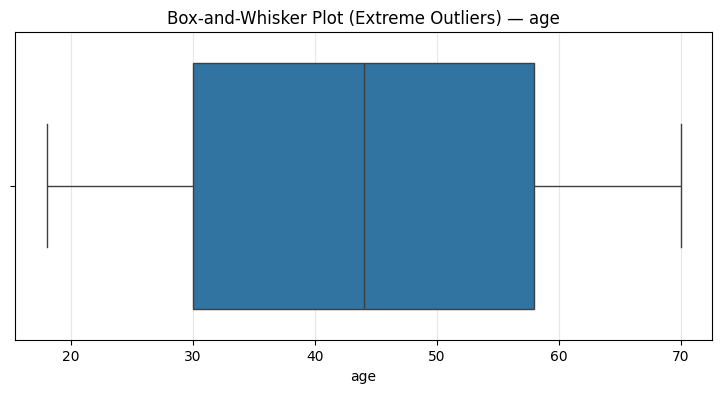

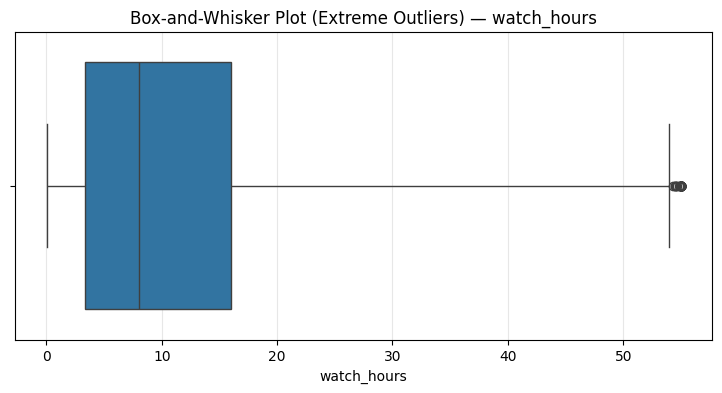

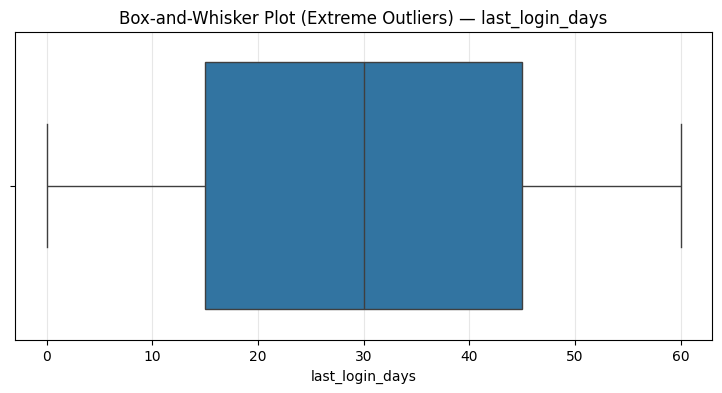

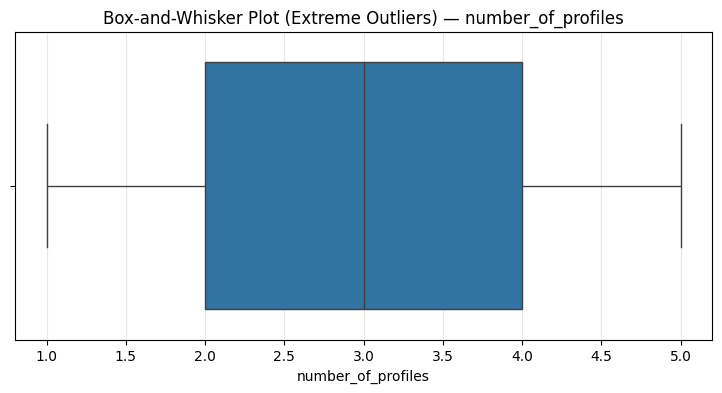

In [ ]:
for column in numeric_columns:
    plt.figure(figsize=(9, 4))

    # Setting whis=3.0 flags only extreme outliers (> 3 * IQR)
    sns.boxplot(
        data=df,
        x=column,
        whis=3.0
    )

    plt.title(f"Box-and-Whisker Plot (Extreme Outliers) — {column}")
    plt.xlabel(column)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

Deletion of Final Outliers

In [ ]:
# # Drop rows where any numeric column flagged True
# df_old=df.copy()
# df = df[~iqr_outlier_flags.any(axis=1)]

# print(f"Original shape: {df_old.shape}")
# print(f"Cleaned shape:  {df.shape}")

-------------------------------------------------------------

**Data Visualisation**

For continious data *<'age', 'watch_hours', 'last_login_days', 'avg_watch_time_per_day'>*

------------------------------------------------------------
Column: age
Skewness: 0.0063
Mean:     43.85
Median:   44.00


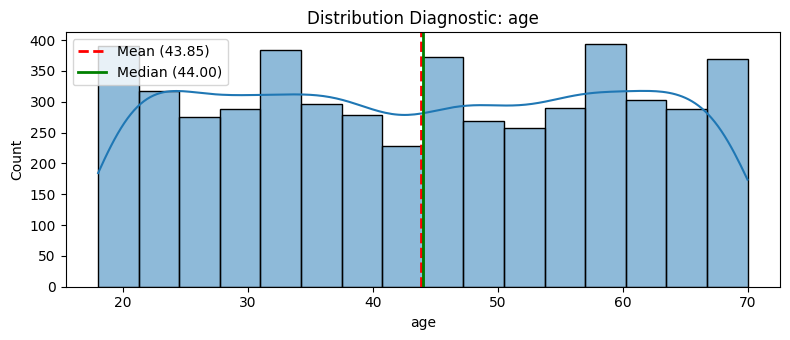

------------------------------------------------------------
Column: watch_hours
Skewness: 1.6706
Mean:     11.49
Median:   8.00


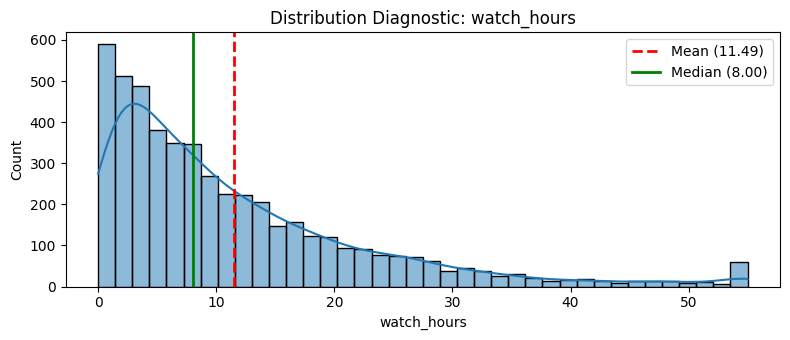

------------------------------------------------------------
Column: last_login_days
Skewness: -0.0260
Mean:     30.09
Median:   30.00


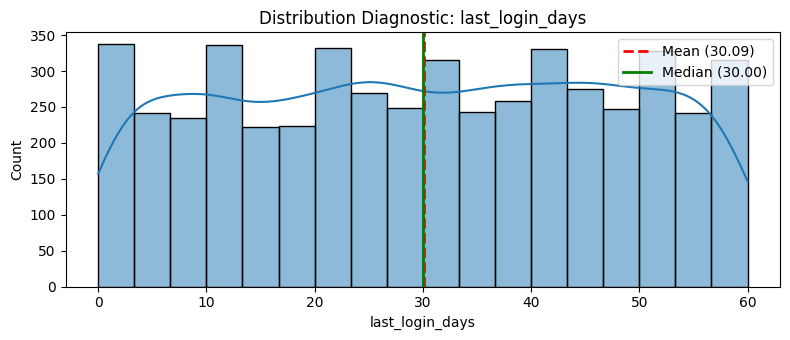

In [ ]:
num_cols = df[['age', 'watch_hours', 'last_login_days']].columns

for col in num_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()

    print("-" * 60)
    print(f"Column: {col}")
    print(f"Skewness: {skew_val:.4f}")
    print(f"Mean:     {mean_val:.2f}")
    print(f"Median:   {median_val:.2f}")

    plt.figure(figsize=(8, 3.5))
    sns.histplot(df[col], kde=True)
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean ({mean_val:.2f})",
    )
    plt.axvline(
        median_val,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Median ({median_val:.2f})",
    )
    plt.title(f"Distribution Diagnostic: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

For Multi-Categorical Variables *<'gender', 'subscription_type', 'region', 'device', 'favorite_genre'>*

------------------------------------------------------------
Column: gender
        Count  Percentage (%)
gender                       
female   1711           34.22
male     1654           33.08
other    1635           32.70


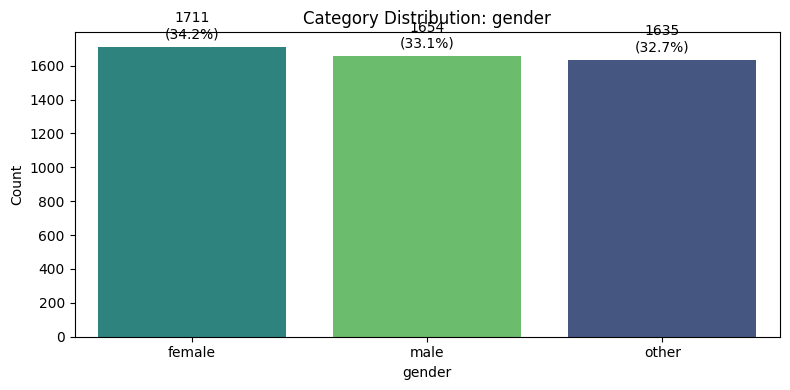

------------------------------------------------------------
Column: subscription_type
                   Count  Percentage (%)
subscription_type                       
premium             1693           33.86
basic               1661           33.22
standard            1646           32.92


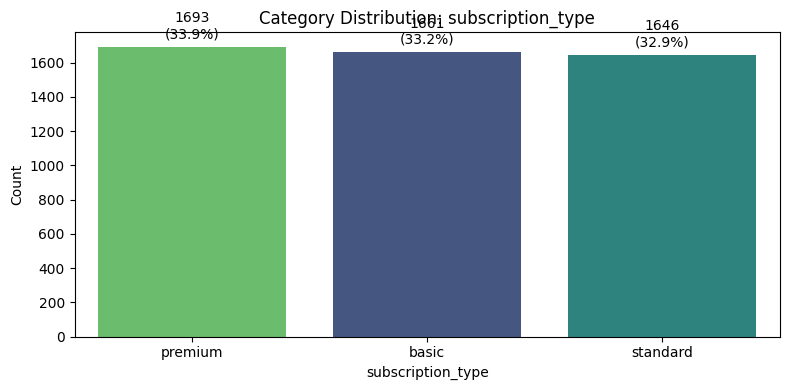

------------------------------------------------------------
Column: region
               Count  Percentage (%)
region                              
south america    873           17.46
europe           867           17.34
north america    851           17.02
asia             841           16.82
africa           803           16.06
oceania          765           15.30


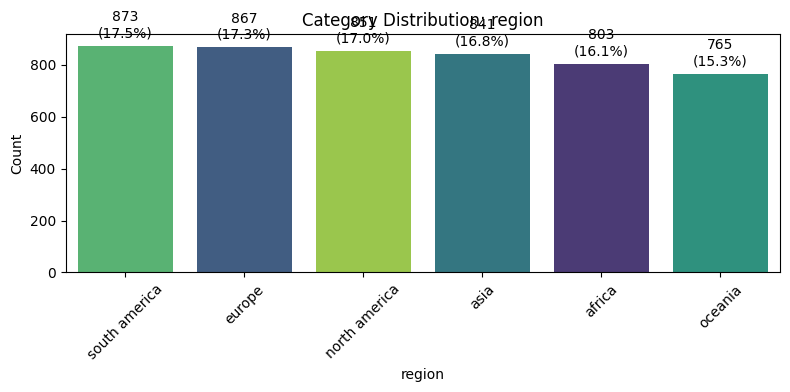

------------------------------------------------------------
Column: number_of_profiles
                    Count  Percentage (%)
number_of_profiles                       
5                    1034           20.68
2                    1001           20.02
4                     999           19.98
3                     994           19.88
1                     972           19.44


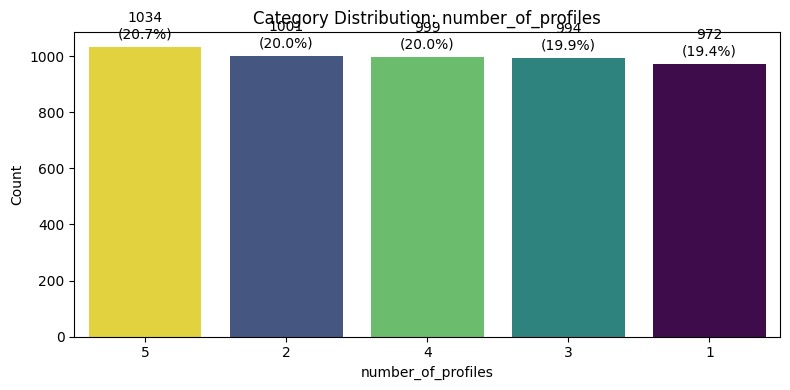

------------------------------------------------------------
Column: device
         Count  Percentage (%)
device                        
tablet    1048           20.96
laptop    1006           20.12
mobile    1004           20.08
tv         993           19.86
desktop    949           18.98


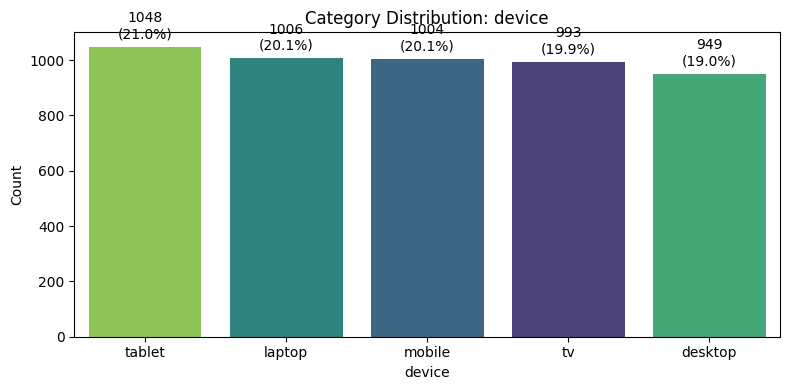

------------------------------------------------------------
Column: favorite_genre
                Count  Percentage (%)
favorite_genre                       
drama             731           14.62
documentary       729           14.58
romance           725           14.50
sci-fi            720           14.40
horror            713           14.26
action            697           13.94
comedy            685           13.70


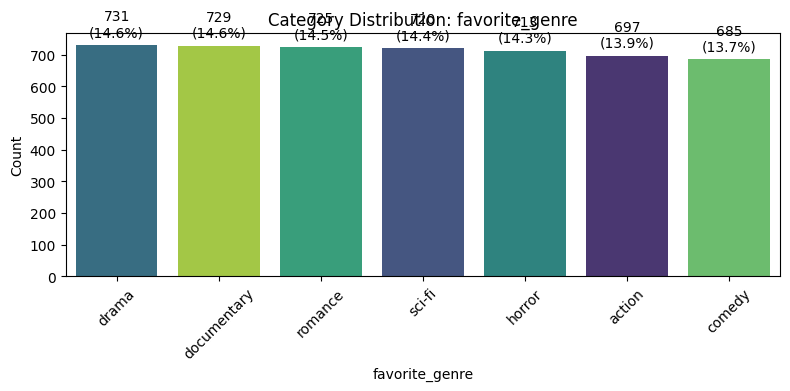

In [ ]:
cat_cols = df[['gender', 'subscription_type', 'region', 'number_of_profiles', 'device', 'favorite_genre']].columns

for col in cat_cols:
    # Calculate counts and percentage proportions
    val_counts = df[col].value_counts(dropna=False)
    val_pcts = df[col].value_counts(normalize=True, dropna=False) * 100

    summary_df = pd.DataFrame(
        {"Count": val_counts, "Percentage (%)": val_pcts.round(2)}
    )

    print("-" * 60)
    print(f"Column: {col}")
    print(summary_df)

    # Plot distribution
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        data=df,
        x=col,
        order=val_counts.index,
        palette="viridis",
        hue=col,
        legend=False,
    )

    # Annotate bars with frequency count and percentage
    total = len(df[col].dropna())
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f"{(height / total) * 100:.1f}%"
            ax.annotate(
                f"{int(height)}\n({percentage})",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                xytext=(0, 4),
                textcoords="offset points",
            )

    plt.title(f"Category Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45 if df[col].nunique() > 5 else 0)
    plt.tight_layout()
    plt.show()

Pie Representation for Binary Variable (Churned)

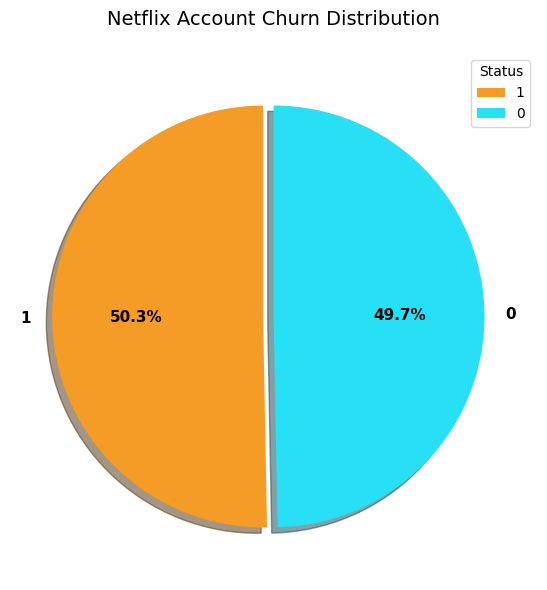

In [ ]:
churn_counts = df['churned'].value_counts()

plt.figure(figsize=(6, 6))
colors = ["#F59C27", "#27E0F5"]

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors[: len(churn_counts)],
    explode=[0.05] + [0] * (len(churn_counts) - 1),
    shadow=True,
    textprops={"fontsize": 11, "weight": "bold"},
)

plt.title("Netflix Account Churn Distribution", fontsize=14, pad=20)
plt.legend(title="Status", loc="upper right")
plt.tight_layout()
plt.show()

Correlation coefficient (r)

,age,watch_hours,last_login_days,number_of_profiles
age,1.0000,0.0277,0.0168,0.0173
watch_hours,0.0277,1.0000,0.0033,0.0133
last_login_days,0.0168,0.0033,1.0000,0.0172
number_of_profiles,0.0173,0.0133,0.0172,1.0000


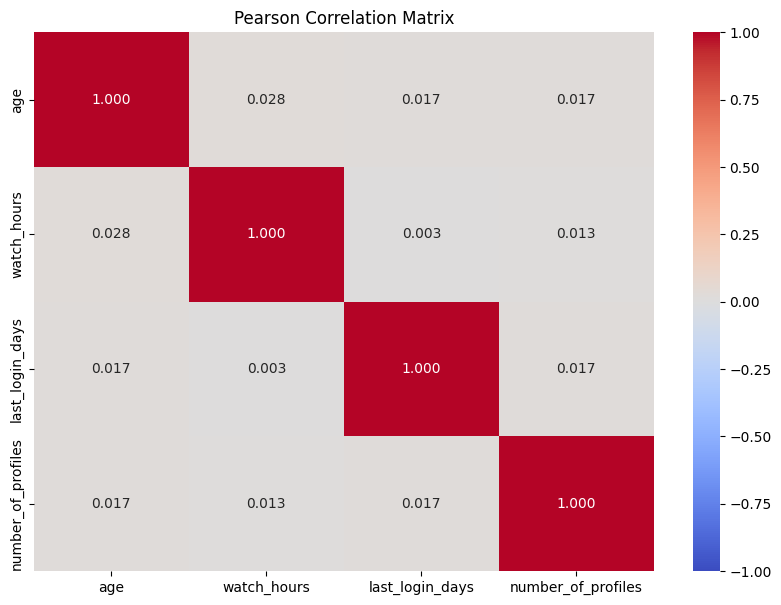

In [ ]:
# Correlation matrix
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

Encode multi-categorical into values

In [ ]:
# Select categorical columns to encode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Make a copy of the dataframe to avoid modifying original in-place if needed
df_encoded = df.copy()

# Initialize and fit OrdinalEncoder
encoder = OrdinalEncoder()
encoded_values = encoder.fit_transform(df_encoded[categorical_cols])

# Convert to 1-based index integer encoding
for i, col in enumerate(categorical_cols):
    df_encoded[col] = encoded_values[:, i].astype(int) + 1

# Ensure any remaining categorical columns are converted
df_encoded = pd.get_dummies(df_encoded, dtype=int)
display(df_encoded.head())

,age,gender,subscription_type,watch_hours,last_login_days,region,device,churned,payment_method,number_of_profiles,favorite_genre
0,51,3,1,14.73,29,1,5,1,4,1,1
1,47,3,3,0.70,19,3,3,1,4,5,7
2,27,1,3,16.32,10,2,5,0,2,2,4
3,53,3,2,4.51,12,5,5,1,2,2,5
4,56,3,3,1.89,13,1,3,1,2,2,1


Correlation Coefficients to watch_hours

In [ ]:
corr_matrix = df_encoded.corr()

# 3. Correlation with watch_hours
watch_corr = (
    corr_matrix["watch_hours"].drop("watch_hours").sort_values(ascending=False)
)

print("=== Correlation with watch_hours ===")
print(watch_corr)

=== Correlation with watch_hours ===
age                   0.027661
favorite_genre        0.018872
number_of_profiles    0.013268
region                0.010916
subscription_type     0.006697
gender                0.004502
last_login_days       0.003274
payment_method       -0.012759
device               -0.017644
churned              -0.499182
Name: watch_hours, dtype: float64


Correlation Coefficients to churned

In [ ]:
# Correlation of all features with churned
churn_corr = (
    corr_matrix["churned"].drop("churned").sort_values(ascending=False)
)
print("\n=== Correlation with churned ===")
print(churn_corr)


=== Correlation with churned ===
last_login_days       0.471590
payment_method        0.012535
region                0.011231
device               -0.001253
age                  -0.003515
gender               -0.010648
favorite_genre       -0.026492
subscription_type    -0.133517
number_of_profiles   -0.158614
watch_hours          -0.499182
Name: churned, dtype: float64


Correlation Coefficients to age

In [ ]:
# Correlation of all features with age
age_corr = (
    corr_matrix["age"].drop("age").sort_values(ascending=False)
)
print("\n=== Correlation with age ===")
print(age_corr)


=== Correlation with age ===
watch_hours           0.027661
number_of_profiles    0.017333
last_login_days       0.016769
device                0.011361
gender                0.007863
payment_method        0.001355
churned              -0.003515
favorite_genre       -0.003905
region               -0.011430
subscription_type    -0.016379
Name: age, dtype: float64


Representation

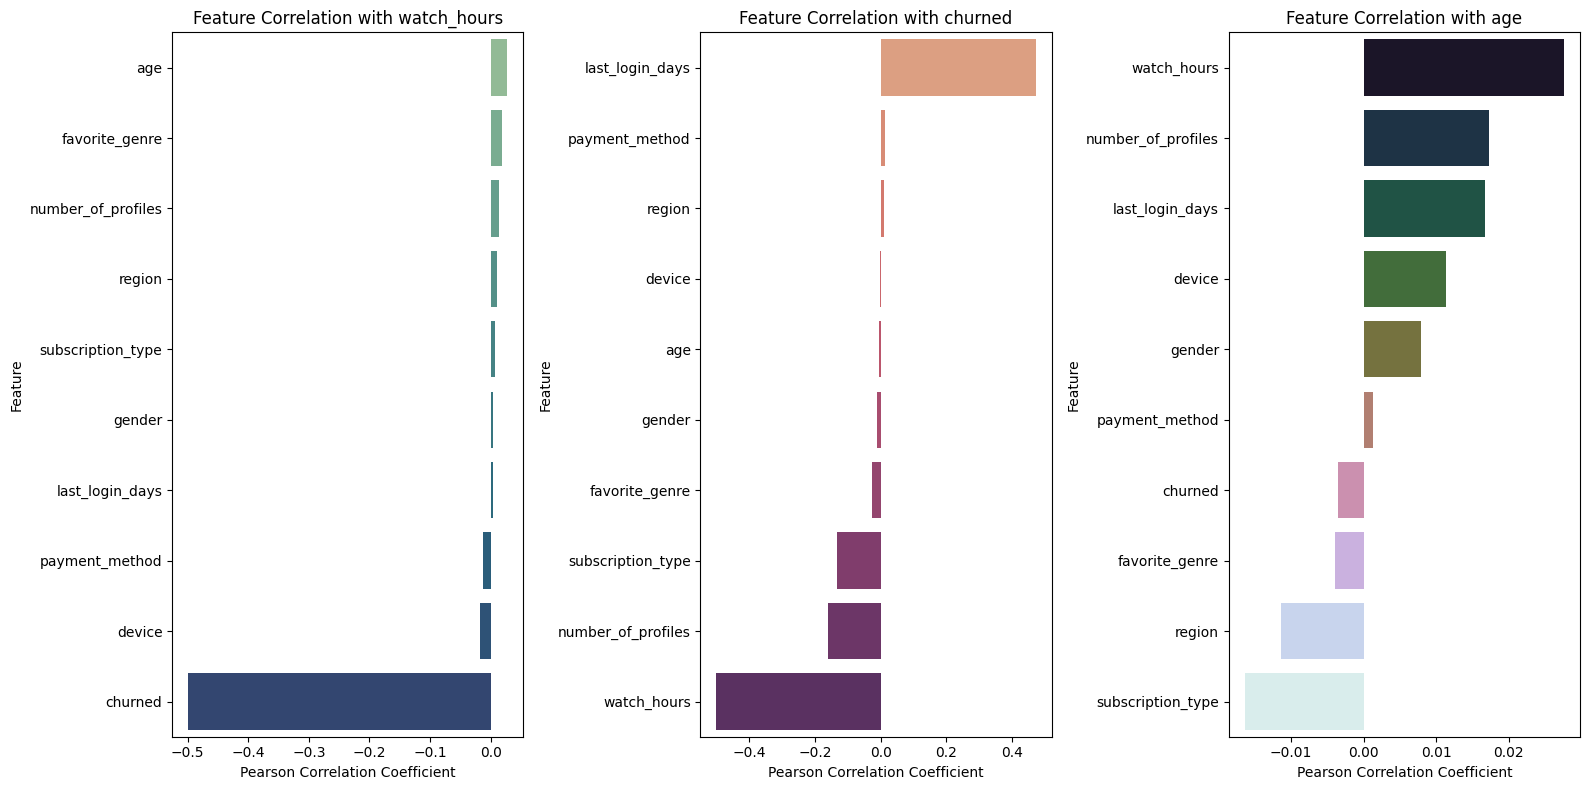

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# Plot Watch Hours correlations
sns.barplot(
    x=watch_corr.values,
    y=watch_corr.index,
    ax=axes[0],
    palette="crest",
    hue=watch_corr.index,
    legend=False,
)
axes[0].set_title("Feature Correlation with watch_hours")
axes[0].set_xlabel("Pearson Correlation Coefficient")
axes[0].set_ylabel("Feature")

# Plot Churned correlations
sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index,
    ax=axes[1],
    palette="flare",
    hue=churn_corr.index,
    legend=False,
)
axes[1].set_title("Feature Correlation with churned")
axes[1].set_xlabel("Pearson Correlation Coefficient")
axes[1].set_ylabel("Feature")

# Plot Age correlations (FIXED: changed ax=axes[1] to ax=axes[2])
sns.barplot(
    x=age_corr.values,
    y=age_corr.index,
    ax=axes[2],
    palette="cubehelix",
    hue=age_corr.index,
    legend=False,
)
axes[2].set_title("Feature Correlation with age")
axes[2].set_xlabel("Pearson Correlation Coefficient")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.show()

#TASK 2
**Hypothesis testing and statistical inference**

Print Functions

In [ ]:
ALPHA = 0.05

def decision(p_value, alpha=ALPHA):
    return "Reject H0" if p_value < alpha else "Do not reject H0"

def print_result(test_name, h0, h1, statistic_name, statistic, p_value, alpha=ALPHA):
    print("=" * 80)
    print(test_name)
    print("-" * 80)
    print("H0:", h0)
    print("H1:", h1)
    print(f"{statistic_name} = {statistic:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"alpha = {alpha}")
    print("Decision:", decision(p_value, alpha))
    if p_value < alpha:
        print("Interpretation: There is statistically significant evidence against H0.")
    else:
        print("Interpretation: There is not sufficient statistical evidence against H0.")

**Shapiro-Wilk test for Normality**

In [ ]:
x = df["watch_hours"].dropna()

#Normality Check via Shapiro-Wilk

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

Shapiro-Wilk test for normality
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8299
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


Normalization via logarithm

In [ ]:
df["log_watch_hours"] = np.log1p(df["watch_hours"])
display(df.head())

,age,gender,subscription_type,watch_hours,last_login_days,region,device,churned,payment_method,number_of_profiles,favorite_genre,log_watch_hours
0,51,other,basic,14.73,29,africa,tv,1,gift card,1,action,2.755570
1,47,other,standard,0.70,19,europe,mobile,1,gift card,5,sci-fi,0.530628
2,27,female,standard,16.32,10,asia,tv,0,crypto,2,drama,2.851862
3,53,other,premium,4.51,12,oceania,tv,1,crypto,2,horror,1.706565
4,56,other,standard,1.89,13,africa,mobile,1,crypto,2,action,1.061257


Display Data

------------------------------------------------------------
Column: log_watch_hours
Skewness: -0.1840
Mean:     2.13
Median:   2.20


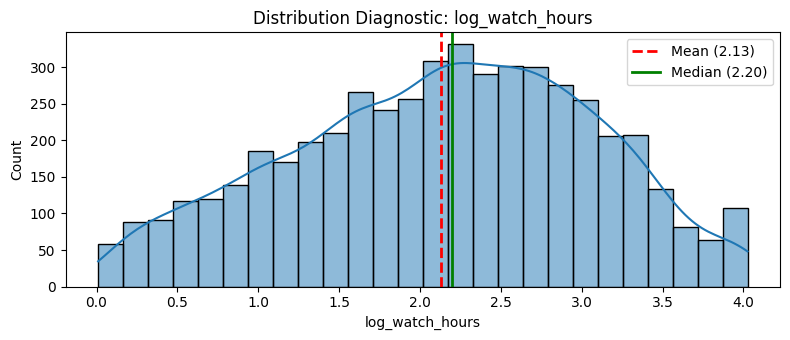

In [ ]:
num_cols = df[['log_watch_hours']].columns

for col in num_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()

    print("-" * 60)
    print(f"Column: {col}")
    print(f"Skewness: {skew_val:.4f}")
    print(f"Mean:     {mean_val:.2f}")
    print(f"Median:   {median_val:.2f}")

    plt.figure(figsize=(8, 3.5))
    sns.histplot(df[col], kde=True)
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean ({mean_val:.2f})",
    )
    plt.axvline(
        median_val,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Median ({median_val:.2f})",
    )
    plt.title(f"Distribution Diagnostic: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

New Shapiro-Wilk Test

In [ ]:
x = df["log_watch_hours"].dropna()

#Normality Check via Shapiro-Wilk

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

Shapiro-Wilk test for normality
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.9856
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


**One Sample T-Test**

Is the population average monthly streaming time (watch_hours) equal to 11.0 hours?
$\begin{cases}
H_0: \mu = 11.0 \\
H_1: \mu \neq 11.0
\end{cases}$

In [ ]:
#One-Sample t-test
x = df["watch_hours"].dropna()

mu0 =11.0

# Two-sided alternative
t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='two-sided')

# Right-sided alternative
#t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='greater')

#Left-sided alternative
#t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='less')

print_result(
    test_name = "One sample t-test",
    h0 = "μ = 11.0",
    h1 = "μ ≠ 11.0",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Sample mean = {x.mean():.2f}")
print(f"Sample standard deviation = {x.std(ddof=1):.2f}")
print(f"Sample size = {len(x)}")

One sample t-test
--------------------------------------------------------------------------------
H0: μ = 11.0
H1: μ ≠ 11.0
t = 3.0756
p-value = 0.002112
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Sample mean = 11.49
Sample standard deviation = 11.23
Sample size = 5000


In [ ]:
#One-Sample t-test
x = df["age"].dropna()

mu0 =12.0

# Two-sided alternative
# t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='two-sided')

# Right-sided alternative
t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='greater')

#Left-sided alternative
#t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='less')

print_result(
    test_name = "One sample t-test",
    h0 = "μ = 43.0",
    h1 = "μ ≠ 43.0",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Sample mean = {x.mean():.2f}")
print(f"Sample standard deviation = {x.std(ddof=1):.2f}")
print(f"Sample size = {len(x)}")

One sample t-test
--------------------------------------------------------------------------------
H0: μ = 43.0
H1: μ ≠ 43.0
t = 145.2766
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Sample mean = 43.85
Sample standard deviation = 15.50
Sample size = 5000


In [ ]:
#One-Sample t-test
x = df["log_watch_hours"].dropna()

mu0 = 2.0

# Two-sided alternative
t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='two-sided')

# Right-sided alternative
# t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='greater')

#Left-sided alternative
# t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='less')

print_result(
    test_name = "One sample t-test",
    h0 = "μ = 2.0",
    h1 = "μ ≠ 2.0",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Sample mean = {x.mean():.2f}")
print(f"Sample standard deviation = {x.std(ddof=1):.2f}")
print(f"Sample size = {len(x)}")

One sample t-test
--------------------------------------------------------------------------------
H0: μ = 2.0
H1: μ ≠ 2.0
t = 9.9570
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Sample mean = 2.13
Sample standard deviation = 0.93
Sample size = 5000


**Hypothesis test for the population proportion**

Is the population proportion of churn rate equal to **0.50** (or 50%)?

$\begin{cases}
H_0: p = 0.50 \\
H_1: p \neq 0.50
\end{cases}$

In [ ]:
churn = df["churned"].dropna()
success = (churn == 1).sum()
n = len(churn)
p0 = 0.5

# Two-sided alternative
z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="two-sided")

# Right-sided alternative
# z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="larger")

# Left-sided alternative
# z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="smaller")

print_result(
    test_name = "One sample population proportion test",
    h0 = "p = 0.50",
    h1 = "p ≠ 0.50",
    statistic_name = "z",
    statistic = z_stat,
    p_value = p_value
)

print(f"Observed proportion (churned = 1) = {success/n:.4f}")
print(f"Total churned subscribers = {success}")
print(f"Total subscribers (n) = {n}")

One sample population proportion test
--------------------------------------------------------------------------------
H0: p = 0.50
H1: p ≠ 0.50
z = 0.4243
p-value = 0.671368
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.
Observed proportion (churned = 1) = 0.5030
Total churned subscribers = 2515
Total subscribers (n) = 5000


**Hypothesis testing for correlation**

Is there a statistically significant linear correlation between the **watch_hours** of customers and their **last_login_days amount**?

$\begin{cases}
H_0: \rho = 0 \\
H_1: \rho \neq 0
\end{cases}$

Variables:
- `watch_hours`
- `last_login_days`

The Shapiro-Wilk test is performed for both variables before testing for correlation.

Shapiro

In [ ]:
x = df["watch_hours"].dropna()

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality: watch_hours",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

x = df["last_login_days"].dropna()

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality: last_login_days",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

Shapiro-Wilk test for normality: watch_hours
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8299
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Shapiro-Wilk test for normality: last_login_days
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.9550
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


Correlation testing

In [ ]:
corr_data = df[["watch_hours", "last_login_days"]].dropna()

r, p_value = stats.pearsonr(corr_data["watch_hours"], corr_data["last_login_days"], alternative='two-sided')

print_result(
    test_name = "Hypothesis test for correlation",
    h0 = "ρ = 0",
    h1 = "ρ ≠ 0",
    statistic_name = "r",
    statistic = r,
    p_value = p_value
)

print(f"n = {len(corr_data)}")

Hypothesis test for correlation
--------------------------------------------------------------------------------
H0: ρ = 0
H1: ρ ≠ 0
r = 0.0033
p-value = 0.816948
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.
n = 5000


Presentation

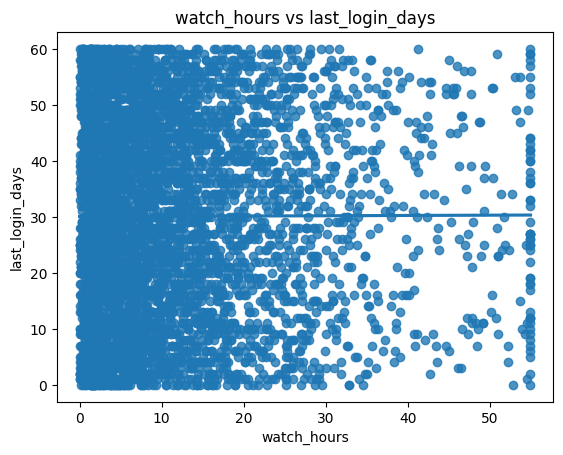

In [ ]:
sns.regplot(
    data=corr_data,
    x="watch_hours",
    y="last_login_days",
    ci=None
)
plt.title("watch_hours vs last_login_days")
plt.show()

**Two independent samples t-test**


Do active subscribers (churned = 0) and churned subscribers (churned = 1) have different average watch_hours?

$\begin{cases}
H_0: \mu_x = \mu_y \\
H_1: \mu_x \neq \mu_y
\end{cases}$

Data Selection

In [ ]:
ind_data = df[["churned", "watch_hours"]].dropna()

active = ind_data.loc[ind_data["churned"] == 0, "watch_hours"]
churned = ind_data.loc[ind_data["churned"] == 1, "watch_hours"]

print(f"Active: n = {len(active)}, mean = {active.mean():.4f}, var = {active.var(ddof=1):.4f}")
print(f"Churned: n = {len(churned)}, mean = {churned.mean():.4f}, var = {churned.var(ddof=1):.4f}")

Active: n = 2485, mean = 17.1253, var = 160.7039
Churned: n = 2515, mean = 5.9185, var = 29.3653


Shapiro-Wilk Test

In [ ]:
# Test normality using Shapiro-Wilk test

stat, p_value = stats.shapiro(active)

print_result(
    test_name = "Shapiro-Wilk test for normality: Watch hours for active",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

stat, p_value = stats.shapiro(churned)

print_result(
    test_name = "Shapiro-Wilk test for normality: Watch hours for churned",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)


Shapiro-Wilk test for normality: Watch hours for active
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.9010
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Shapiro-Wilk test for normality: Watch hours for churned
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8634
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


Test equality of variances using Levene's test

In [ ]:
print("\n--- Levene's test for equality of variances ---")

levene_stat, levene_p = stats.levene(active, churned, center="median")

print(f"Levene statistic = {levene_stat:.4f}")
print(f"Levene p-value = {levene_p:.4f}")

if levene_p < ALPHA:
    print(
        f"p-value < {ALPHA}: Reject H0."
    )
    print(
        "There is evidence that the population variances are different."
    )
    equal_variances = False
else:
    print(
        f"p-value >= {ALPHA}: Do not reject H0."
    )
    print(
        "There is insufficient evidence that the population variances are different."
    )
    equal_variances = True


--- Levene's test for equality of variances ---
Levene statistic = 867.3260
Levene p-value = 0.0000
p-value < 0.05: Reject H0.
There is evidence that the population variances are different.


Independent samples t-test

In [ ]:
# Select and perform the appropriate t-test

print("\n--- Independent samples t-test ---")

if equal_variances:
    # Equal variances assumed
    t_stat, p_value = stats.ttest_ind(active, churned, equal_var=True)
    selected_test = "Independent samples t-test (equal variances assumed)"
else:
    # Equal variances not assumed
    t_stat, p_value = stats.ttest_ind(active, churned, equal_var=False)
    selected_test = "Welch's independent samples t-test"

print(f"Selected test: {selected_test}")

print_result(
    test_name = "Two independent-samples t-test",
    h0 = "μ_x = μ_y",
    h1 = "μ_x ≠ μ_y",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Active sample mean = {active.mean():.4f}, n = {len(active)}")
print(f"Churned sample mean = {churned.mean():.4f}, n = {len(churned)}")


--- Independent samples t-test ---
Selected test: Welch's independent samples t-test
Two independent-samples t-test
--------------------------------------------------------------------------------
H0: μ_x = μ_y
H1: μ_x ≠ μ_y
t = 40.5592
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Active sample mean = 17.1253, n = 2485
Churned sample mean = 5.9185, n = 2515


**Paired samples t-test** (SKIP - We don't have two continious data before and after)

**Equality of two population proportions**

Are the population proportions of customers with inactive accounts buying **basic subscription** and **premium subscription** equal?

$\begin{cases}
H_0: p_A = p_B \\
H_1: p_A \neq p_B
\end{cases}$


Variables:
- `subscription_type == basic`
- `subscription_type == premium`
for `churned`

In [ ]:
basic_subscribers = df[df["subscription_type"] == "basic"]["churned"].dropna()
premium_subscribers = df[df["subscription_type"] == "premium"]["churned"].dropna()

success_basic = (basic_subscribers == 1).sum()
success_premium = (premium_subscribers == 1).sum()

n_basic = len(basic_subscribers)
n_premium = len(premium_subscribers)

z_stat, p_value = proportions_ztest(
    count=[success_basic, success_premium],
    nobs=[n_basic, n_premium],
    alternative="two-sided"
)

print_result(
    test_name = "Equality of two population proportions: Churn Rate (Basic vs Premium)",
    h0 = "p_A = p_B",
    h1 = "p_A ≠ p_B",
    statistic_name = "z",
    statistic = z_stat,
    p_value = p_value
)

print(f"Basic tier churn rate = {success_basic/n_basic:.4f} (n={n_basic})")
print(f"Premium tier churn rate = {success_premium/n_premium:.4f} (n={n_premium})")

Equality of two population proportions: Churn Rate (Basic vs Premium)
--------------------------------------------------------------------------------
H0: p_A = p_B
H1: p_A ≠ p_B
z = 10.5091
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Basic tier churn rate = 0.6183 (n=1661)
Premium tier churn rate = 0.4371 (n=1693)


**Chi-square (χ²) goodness-of-fit test**


Is the subscriber distribution across subscription_type evenly split across tiers (33.3% Basic, 33.3% Standard, 33.3% Premium)?

- Basic = 0.33 (33%)
- Standard = 0.33 (33%)
- Premium = 0.33 (33%)

$\begin{cases}
H_0: p_1 = 0.33, p_2 = 0.33, p_3 = 0.33 \\
H_1: \text{At least one } p_i \neq p_{i}^{0} (i=1, 2, ..., n)
\end{cases}$


Variable: `subscription_type`

In [ ]:
tiers = df["subscription_type"].dropna().str.strip()

categories = ["basic", "standard", "premium"]
observed = tiers.value_counts().reindex(categories, fill_value=0).values
hypothesized_proportions = np.array([1/3, 1/3, 1/3])
expected = tiers.size * hypothesized_proportions

chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)

print_result(
    test_name="Chi-square goodness-of-fit test: Subscription Tiers",
    h0="p_Basic = 0.333, p_Standard = 0.333, p_Premium = 0.333",
    h1="At least one tier proportion differs",
    statistic_name="χ²",
    statistic=chi2_stat,
    p_value=p_value
)

display(pd.DataFrame({
    "Category": categories,
    "Observed": observed,
    "Expected": expected,
    "Observed Proportion": observed / observed.sum(),
    "Expected Proportion": hypothesized_proportions
}))

Chi-square goodness-of-fit test: Subscription Tiers
--------------------------------------------------------------------------------
H0: p_Basic = 0.333, p_Standard = 0.333, p_Premium = 0.333
H1: At least one tier proportion differs
χ² = 0.6916
p-value = 0.707654
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.


,Category,Observed,Expected,Observed Proportion,Expected Proportion
0,basic,1661,1666.666667,0.3322,0.333333
1,standard,1646,1666.666667,0.3292,0.333333
2,premium,1693,1666.666667,0.3386,0.333333


**Chi-square (χ²) goodness-of-fit test**


Is the subscriber distribution across subscription_type evenly split across tiers (33.3% Basic, 33.3% Standard, 33.3% Premium)?

- Basic = 0.33 (33%)
- Standard = 0.33 (33%)
- Premium = 0.33 (33%)

$\begin{cases}
H_0: p_1 = 0.33, p_2 = 0.33, p_3 = 0.33 \\
H_1: \text{At least one } p_i \neq p_{i}^{0} (i=1, 2, ..., n)
\end{cases}$


Variable: `subscription_type`

In [ ]:
tiers = df["region"].dropna().str.strip()

categories = ["africa", "asia", "europe","north america", "oceania", "south america"]
observed = tiers.value_counts().reindex(categories, fill_value=0).values
hypothesized_proportions = np.array([1/6,1/6,1/6,1/6,1/6,1/6])
expected = tiers.size * hypothesized_proportions

chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)

print_result(
    test_name="Chi-square goodness-of-fit test: Regions",
    h0="r_Africa = 0.16, r_Asia = 0.16, r_Europe = 0.16, r_NorthAmerica = 0.16, r_Oceania=0.16 , r_SouthAmerica=0.16",
    h1="At least one tier proportion differs",
    statistic_name="χ²",
    statistic=chi2_stat,
    p_value=p_value
)

display(pd.DataFrame({
    "Category": categories,
    "Observed": observed,
    "Expected": expected,
    "Observed Proportion": observed / observed.sum(),
    "Expected Proportion": hypothesized_proportions
}))

Chi-square goodness-of-fit test: Regions
--------------------------------------------------------------------------------
H0: r_Africa = 0.16, r_Asia = 0.16, r_Europe = 0.16, r_NorthAmerica = 0.16, r_Oceania=0.16 , r_SouthAmerica=0.16
H1: At least one tier proportion differs
χ² = 10.4008
p-value = 0.064643
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.


,Category,Observed,Expected,Observed Proportion,Expected Proportion
0,africa,803,833.333333,0.1606,0.166667
1,asia,841,833.333333,0.1682,0.166667
2,europe,867,833.333333,0.1734,0.166667
3,north america,851,833.333333,0.1702,0.166667
4,oceania,765,833.333333,0.1530,0.166667
5,south america,873,833.333333,0.1746,0.166667


**Chi-square (χ²) test of independence**

Is **churn** status independent of having a specific **payment** option?

$\begin{cases}
H_0: \text{Payment method and Churn satus are independent} \\
H_1: \text{Payment method and Churn satus are dependent}
\end{cases}$

Variables:
- `payment_method`
- `churned`

In [ ]:
ind_table = pd.crosstab(df["payment_method"], df["churned"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(ind_table)

print_result(
    test_name="Chi-square test of independence: Payment Method vs Churn",
    h0="Payment Method and Churn are independent",
    h1="Payment Method and Churn are dependent",
    statistic_name = "χ²",
    statistic = chi2_stat,
    p_value = p_value
)

print("\nObserved frequencies:")
display(ind_table)
print("Expected frequencies:")
display(pd.DataFrame(expected, index=ind_table.index, columns=ind_table.columns))

Chi-square test of independence: Payment Method vs Churn
--------------------------------------------------------------------------------
H0: Payment Method and Churn are independent
H1: Payment Method and Churn are dependent
χ² = 96.9069
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.

Observed frequencies:


churned,0,1
payment_method,,
credit card,549,424
crypto,401,594
debit card,580,450
gift card,412,564
paypal,543,483


Expected frequencies:


churned,0,1
payment_method,,
credit card,483.581,489.419
crypto,494.515,500.485
debit card,511.910,518.090
gift card,485.072,490.928
paypal,509.922,516.078


**Chi-square (χ²) test of homogeneity**

Is the distribution of **subscription type** the same across the four **regions**?

$\begin{cases}
H_0: \text{The distribution of purchase decision is the same across the four regions} \\
H_1: \text{At least one region has a different distribution}
\end{cases}$


Variables:
- `region`
- `subscription_type`

In [ ]:
hom_table = pd.crosstab(df["region"], df["subscription_type"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(hom_table)

print_result(
    test_name = "Chi-square test of homogeneity",
    h0 = "Purchase decision has the same distribution across regions",
    h1 = "At least one region has a different distribution",
    statistic_name = "χ²",
    statistic = chi2_stat,
    p_value = p_value
)

print("\nObserved frequencies:")
display(hom_table)
print("Expected frequencies:")
display(pd.DataFrame(expected, index=hom_table.index, columns=hom_table.columns))


Chi-square test of homogeneity
--------------------------------------------------------------------------------
H0: Purchase decision has the same distribution across regions
H1: At least one region has a different distribution
χ² = 4.9083
p-value = 0.897222
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.

Observed frequencies:


subscription_type,basic,premium,standard
region,,,
africa,260,267,276
asia,285,274,282
europe,284,289,294
north america,290,288,273
oceania,242,273,250
south america,300,302,271


Expected frequencies:


subscription_type,basic,premium,standard
region,,,
africa,266.7566,271.8958,264.3476
asia,279.3802,284.7626,276.8572
europe,288.0174,293.5662,285.4164
north america,282.7022,288.1486,280.1492
oceania,254.1330,259.0290,251.8380
south america,290.0106,295.5978,287.3916


#TASK 3
**Predictive modelling & regression analysis**

Define constants

In [ ]:
ALPHA = 0.05
RANDOM_STATE = 42
TEST_SIZE = 0.20

**Single-Variable Linear Regression**

Data Preparation and display summary statistics

```markdown
Independent Variable (X) : "number_of_profiles", "churned", "age", "last_login_days", "subscription_type_encoded" (base for prediction)

Dependent Variable (Y) : "watch_hours" (which would be predicted)
```

Encode into 1,2,3 for subscription_type

In [ ]:
# Map subscription_type to 1, 2, 3
subscription_mapping = {'basic': 1, 'standard': 2, 'premium': 3}
df['subscription_type_encoded'] = df['subscription_type'].map(subscription_mapping)

# Display the updated DataFrame
display(df.head())

,age,gender,subscription_type,watch_hours,last_login_days,region,device,churned,payment_method,number_of_profiles,favorite_genre,log_watch_hours,subscription_type_encoded
0,51,other,basic,14.73,29,africa,tv,1,gift card,1,action,2.755570,1
1,47,other,standard,0.70,19,europe,mobile,1,gift card,5,sci-fi,0.530628,2
2,27,female,standard,16.32,10,asia,tv,0,crypto,2,drama,2.851862,2
3,53,other,premium,4.51,12,oceania,tv,1,crypto,2,horror,1.706565,3
4,56,other,standard,1.89,13,africa,mobile,1,crypto,2,action,1.061257,2


In [ ]:
linear_regression_features = ["number_of_profiles", "churned", "age", "last_login_days", "subscription_type_encoded"]
predicted_feature = "log_watch_hours"

Feature Statistics

In [ ]:

simple_data_packs = []

for feature in linear_regression_features:
    print("\n" + ("-" * 40))
    print(f"Feature: {feature}")

    # Make sure we select the columns and create a clean copy
    simple_data = df[[feature, predicted_feature]].copy()

    simple_data[feature] = pd.to_numeric(simple_data[feature], errors="coerce")
    simple_data[predicted_feature] = pd.to_numeric(simple_data[predicted_feature], errors="coerce")

    # Store the clean pair in our pack list
    simple_data_packs.append(simple_data)

    print("Dataset shape:", simple_data.shape)
    display(simple_data.head())

    print("Summary statistics:")
    display(simple_data.describe())
    print("-" * 40)


----------------------------------------
Feature: number_of_profiles
Dataset shape: (5000, 2)


,number_of_profiles,log_watch_hours
0,1,2.755570
1,5,0.530628
2,2,2.851862
3,2,1.706565
4,2,1.061257


Summary statistics:


,number_of_profiles,log_watch_hours
count,5000.000000,5000.000000
mean,3.024400,2.131111
std,1.415841,0.931099
min,1.000000,0.009950
25%,2.000000,1.467298
50%,3.000000,2.197225
75%,4.000000,2.834976
max,5.000000,4.025021


----------------------------------------

----------------------------------------
Feature: churned
Dataset shape: (5000, 2)


...

----------------------------------------

----------------------------------------
Feature: subscription_type_encoded
Dataset shape: (5000, 2)


,subscription_type_encoded,log_watch_hours
0,1,2.755570
1,2,0.530628
2,2,2.851862
3,3,1.706565
4,2,1.061257


Summary statistics:


,subscription_type_encoded,log_watch_hours
count,5000.000000,5000.000000
mean,2.006400,2.131111
std,0.819081,0.931099
min,1.000000,0.009950
25%,1.000000,1.467298
50%,2.000000,2.197225
75%,3.000000,2.834976
max,3.000000,4.025021


----------------------------------------


Corelation coefficient (Pearson correlation) and significance test

In [ ]:
for number in range(len(linear_regression_features)):
  print("\n")
  print("-"*30)
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]
  x = simple_data[feature]
  y = simple_data[predicted_feature]
  print(feature)
  r, correlation_p = stats.pearsonr(x, y)

  print("Pearson correlation test")
  print(f"Correlation coefficient (r) = {r:.4f}")
  print(f"p-value = {correlation_p:.6f}")

  if correlation_p < ALPHA:
      print(f"p-value < {ALPHA}: Reject H0. There is evidence of a statistically significant linear correlation.")
  else:
      print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence of a statistically significant linear correlation.")



------------------------------
number_of_profiles
Pearson correlation test
Correlation coefficient (r) = -0.0105
p-value = 0.458717
p-value >= 0.05: Do not reject H0. There is insufficient evidence of a statistically significant linear correlation.


------------------------------
churned
Pearson correlation test
Correlation coefficient (r) = -0.5350
p-value = 0.000000
p-value < 0.05: Reject H0. There is evidence of a statistically significant linear correlation.


------------------------------
age
Pearson correlation test
Correlation coefficient (r) = 0.0239
p-value = 0.091454
p-value >= 0.05: Do not reject H0. There is insufficient evidence of a statistically significant linear correlation.


------------------------------
last_login_days
Pearson correlation test
Correlation coefficient (r) = 0.0043
p-value = 0.759570
p-value >= 0.05: Do not reject H0. There is insufficient evidence of a statistically significant linear correlation.


------------------------------
subscription_ty

Scatter Plot



------------------------------


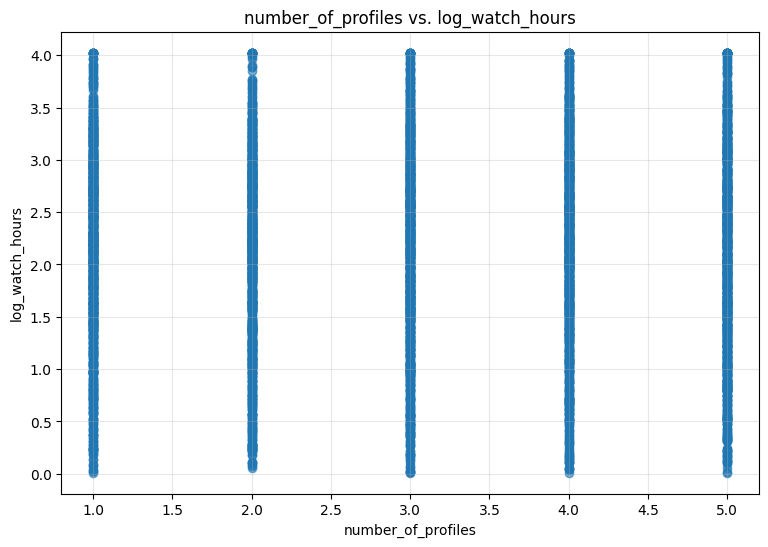



------------------------------


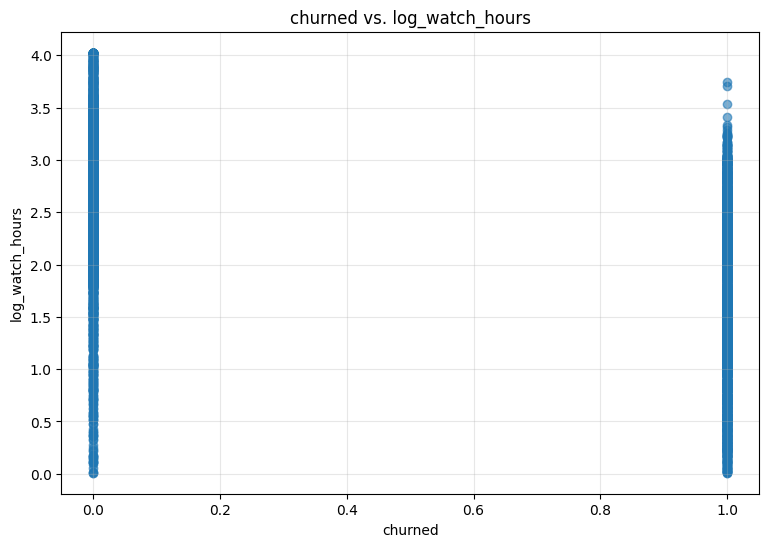



------------------------------


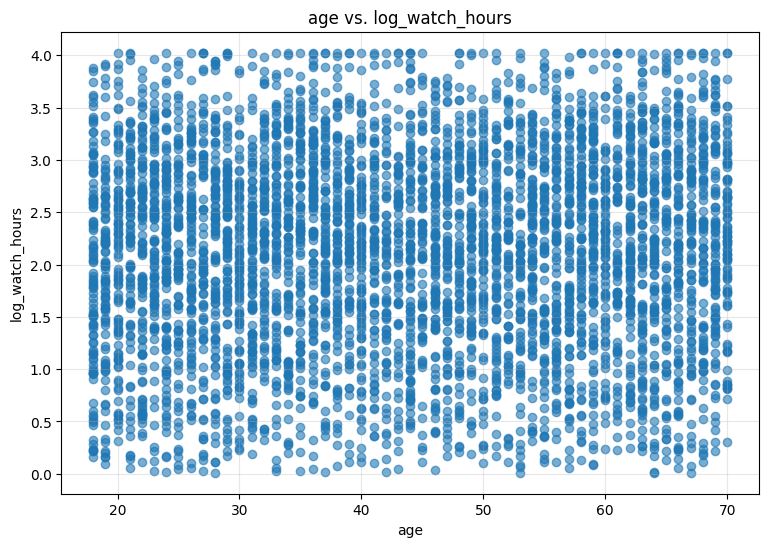



------------------------------


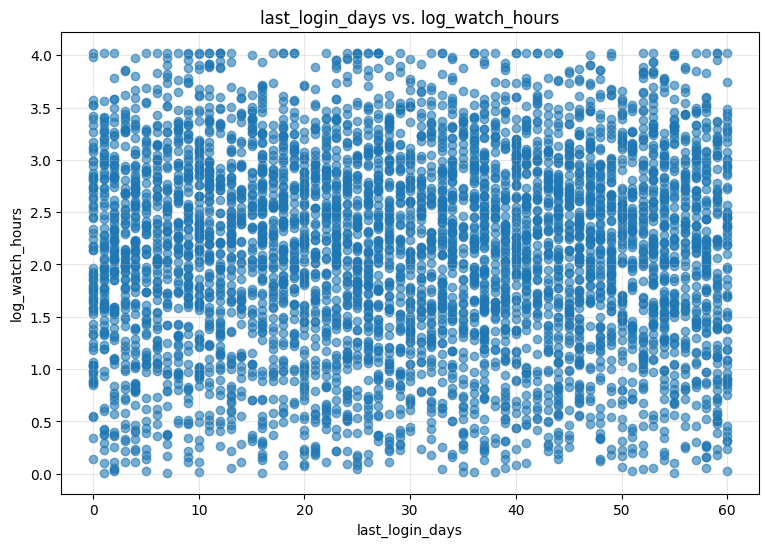



------------------------------


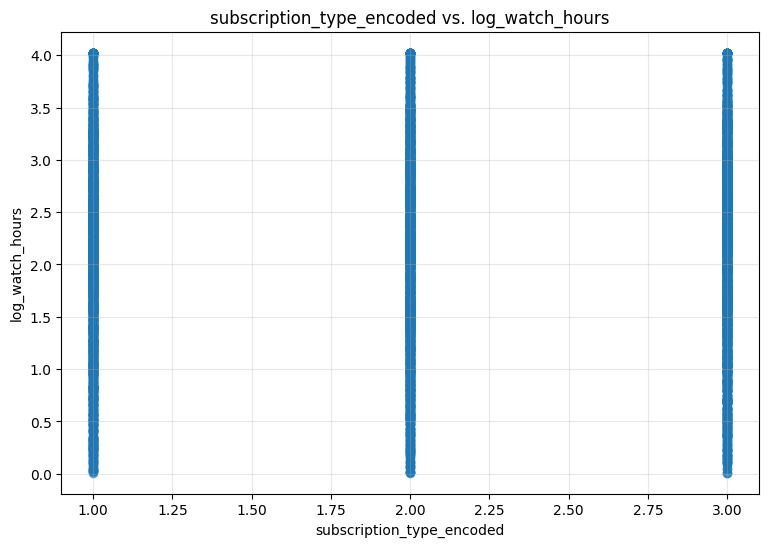

In [ ]:
for number in range(len(linear_regression_features)):
    print("\n")
    print("-"*30)
    simple_data = simple_data_packs[number]
    feature = linear_regression_features[number]

    plt.figure(figsize=(9, 6))
    plt.scatter(simple_data[feature], simple_data[predicted_feature], alpha=0.6)
    plt.xlabel(f"{feature}")
    plt.ylabel(predicted_feature)
    plt.title(f"{feature} vs. {predicted_feature}")
    plt.grid(True, alpha=0.3)
    plt.show()

Train-test split and model fitting

In [ ]:
simple_model_OSL_packs = []
simple_model_packs = []
train_test_tuples = []
for number in range(len(linear_regression_features)):
  print("\n")
  print("-"*30)
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]

  X = simple_data[[feature]]
  y = simple_data[predicted_feature]

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
  )


  print("Training observations:", len(X_train))
  print("Testing observations:", len(X_test))

  simple_model = LinearRegression()
  simple_model.fit(X_train, y_train)
  y_pred = simple_model.predict(X_test)

  intercept = simple_model.intercept_
  slope = simple_model.coef_[0]

  print("\nSimple Linear Regression model coefficients:")
  print(f"Intercept (a) = {intercept:.6f}")
  print(f"Slope (b) = {slope:.6f}")
  print(f"Estimated regression equation: {predicted_feature} = {intercept:.4f} + {slope:.6f} × {feature}")

  # OLS Model
  X_train_sm = sm.add_constant(X_train)
  simple_model_OLS = sm.OLS(y_train, X_train_sm).fit()
  simple_model_OSL_packs.append(simple_model_OLS)
  simple_model_packs.append(simple_model)

  train_test_tuples.append((X_train, X_test, y_train, y_test))

  print(simple_model_OLS.summary())



------------------------------
Training observations: 4000
Testing observations: 1000

Simple Linear Regression model coefficients:
Intercept (a) = 2.150888
Slope (b) = -0.005395
Estimated regression equation: log_watch_hours = 2.1509 + -0.005395 × number_of_profiles
                            OLS Regression Results                            
Dep. Variable:        log_watch_hours   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2664
Date:                Thu, 08 Oct 2026   Prob (F-statistic):              0.606
Time:                        21:33:52   Log-Likelihood:                -5405.0
No. Observations:                4000   AIC:                         1.081e+04
Df Residuals:                    3998   BIC:                         1.083e+04
Df Model:                           1                                         
Covariance Type:   

Testing for significance (t-test) + Testing for significance (F-test)

In [ ]:
for number in range(len(linear_regression_features)):
  print("\n")
  print("-"*30)
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]
  simple_model_OLS = simple_model_OSL_packs[number]
  simple_model = simple_model_packs[number]


  print(f"t-test for the {feature} coefficient")
  print("H0: b = 0")
  print("H1: b ≠ 0")

  t_stat_age = simple_model_OLS.tvalues[feature]
  p_value_age = simple_model_OLS.pvalues[feature]

  print(f"t-statistic = {t_stat_age:.4f}")
  print(f"p-value = {p_value_age:.6f}")

  if p_value_age < ALPHA:
      print(f"p-value < {ALPHA}: Reject H0. {feature} is a statistically significant predictor of {predicted_feature}.")
  else:
      print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that {feature} is a statistically significant predictor.")

  print("F-test for the overall regression model")
  print("H0: b = 0")
  print("H1: b ≠ 0")

  f_stat = simple_model_OLS.fvalue
  f_p_value = simple_model_OLS.f_pvalue

  print(f"F-statistic = {f_stat:.4f}")
  print(f"p-value = {f_p_value:.6f}")

  if f_p_value < ALPHA:
      print(f"p-value < {ALPHA}: Reject H0. The regression model is statistically significant.")
  else:
      print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that the regression model is statistically significant.")



------------------------------
t-test for the number_of_profiles coefficient
H0: b = 0
H1: b ≠ 0
t-statistic = -0.5162
p-value = 0.605769
p-value >= 0.05: Do not reject H0. There is insufficient evidence that number_of_profiles is a statistically significant predictor.
F-test for the overall regression model
H0: b = 0
H1: b ≠ 0
F-statistic = 0.2664
p-value = 0.605769
p-value >= 0.05: Do not reject H0. There is insufficient evidence that the regression model is statistically significant.


------------------------------
t-test for the churned coefficient
H0: b = 0
H1: b ≠ 0
t-statistic = -40.3155
p-value = 0.000000
p-value < 0.05: Reject H0. churned is a statistically significant predictor of log_watch_hours.
F-test for the overall regression model
H0: b = 0
H1: b ≠ 0
F-statistic = 1625.3404
p-value = 0.000000
p-value < 0.05: Reject H0. The regression model is statistically significant.


------------------------------
t-test for the age coefficient
H0: b = 0
H1: b ≠ 0
t-statistic = 1

Regression line

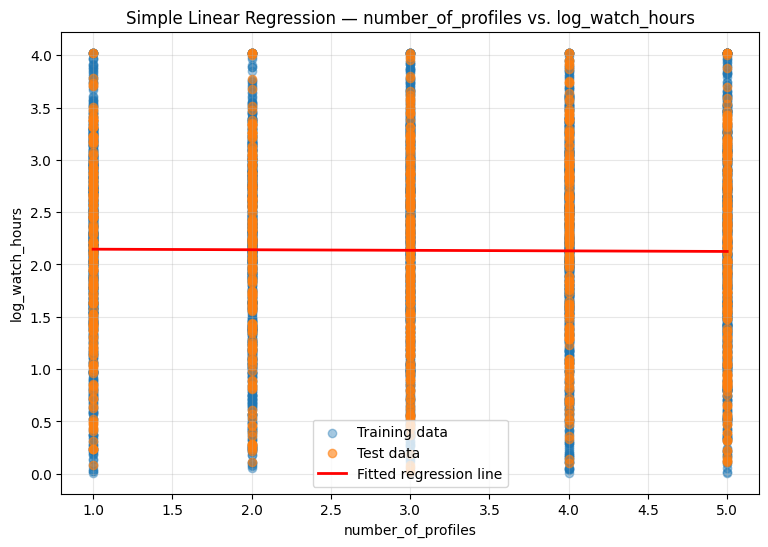

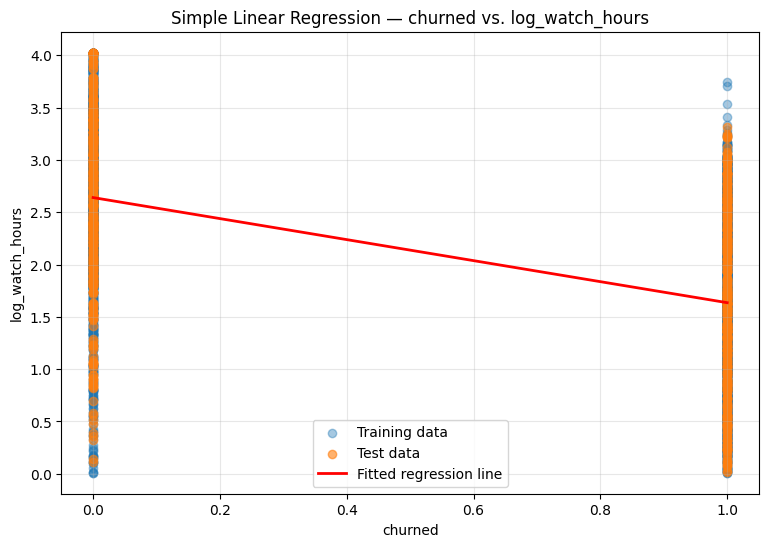

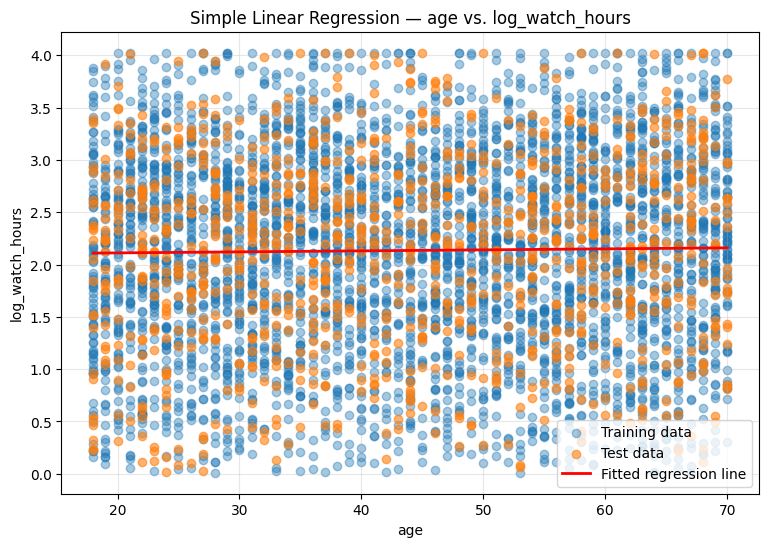

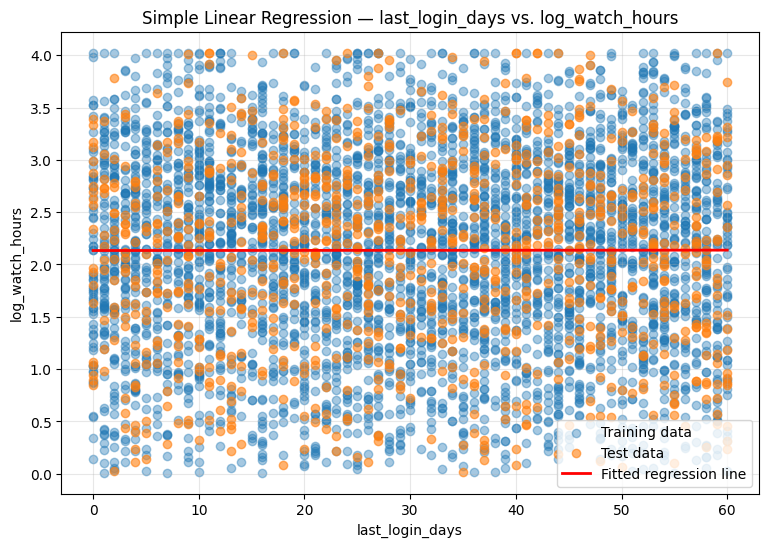

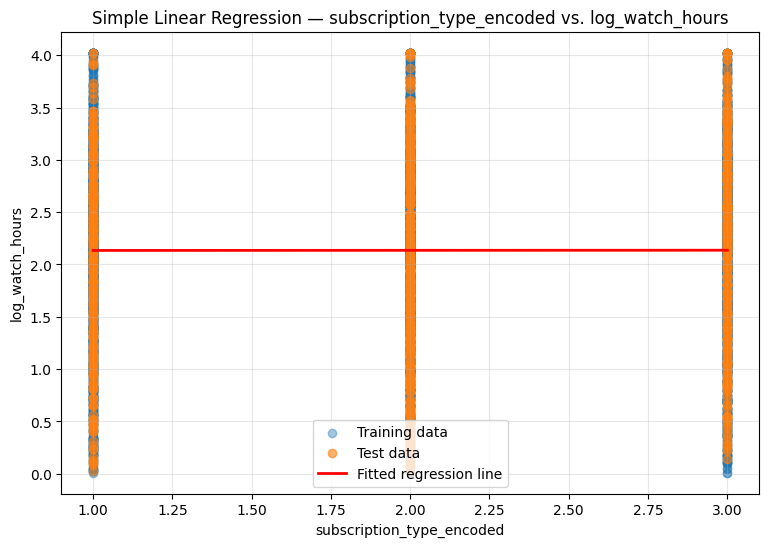

In [ ]:
for number in range(len(linear_regression_features)):
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]
  simple_model = simple_model_packs[number]
  X_train, X_test, y_train, y_test = train_test_tuples[number]


  plot_data = simple_data.copy()
  plot_data["Predicted"] = simple_model.predict(plot_data[[feature]])
  plot_data = plot_data.sort_values(feature)

  plt.figure(figsize=(9, 6))
  plt.scatter(X_train[feature], y_train, alpha=0.4, label="Training data")
  plt.scatter(X_test[feature], y_test, alpha=0.6, label="Test data")
  plt.plot(plot_data[feature], plot_data["Predicted"], color="red", linewidth=2, label="Fitted regression line")
  plt.xlabel(f"{feature}")
  plt.ylabel(f"{predicted_feature}")
  plt.title(f"Simple Linear Regression — {feature} vs. {predicted_feature}")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

Predict the test observations

In [ ]:
simple_predictions_packs = []
y_pred_packs = []
for number in range(len(linear_regression_features)):
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]
  simple_model = simple_model_packs[number]
  X_train, X_test, y_train, y_test = train_test_tuples[number]
  print("\n")
  print("-"*30)
  print(f"Feature: {feature}")

  y_pred = simple_model.predict(X_test)
  simple_predictions = X_test.copy()
  simple_predictions["Actual"] = y_test.values
  simple_predictions["Predicted"] = y_pred
  simple_predictions["Residual"] = simple_predictions["Actual"] - simple_predictions["Predicted"]
  simple_predictions_packs.append(simple_predictions)
  y_pred_packs.append(y_pred)
  display(simple_predictions.head(15))



------------------------------
Feature: number_of_profiles


,number_of_profiles,Actual,Predicted,Residual
1501,5,2.394252,2.123913,0.270339
2586,5,0.223144,2.123913,-1.900769
2653,3,2.255493,2.134703,0.120791
1055,1,2.673459,2.145493,0.527966
705,1,3.226050,2.145493,1.080557
106,2,1.360977,2.140098,-0.779121
589,1,3.217675,2.145493,1.072183
2468,3,1.998774,2.134703,-0.135929
2413,2,3.222071,2.140098,1.081973
1600,5,2.446685,2.123913,0.322773




------------------------------
Feature: churned


,churned,Actual,Predicted,Residual
1501,0,2.394252,2.640335,-0.246082
2586,1,0.223144,1.635414,-1.412270
2653,0,2.255493,2.640335,-0.384841
1055,1,2.673459,1.635414,1.038045
705,1,3.226050,1.635414,1.590636
106,1,1.360977,1.635414,-0.274437
589,1,3.217675,1.635414,1.582261
2468,1,1.998774,1.635414,0.363360
2413,0,3.222071,2.640335,0.581736
1600,0,2.446685,2.640335,-0.193649




------------------------------
Feature: age


,age,Actual,Predicted,Residual
1501,39,2.394252,2.129800,0.264452
2586,18,0.223144,2.109507,-1.886363
2653,19,2.255493,2.110473,0.145021
1055,34,2.673459,2.124969,0.548490
705,29,3.226050,2.120137,1.105913
106,49,1.360977,2.139464,-0.778487
589,62,3.217675,2.152027,1.065648
2468,25,1.998774,2.116271,-0.117498
2413,68,3.222071,2.157825,1.064246
1600,65,2.446685,2.154926,0.291759




------------------------------
Feature: last_login_days


,last_login_days,Actual,Predicted,Residual
1501,22,2.394252,2.134099,0.260153
2586,37,0.223144,2.135049,-1.911905
2653,6,2.255493,2.133086,0.122407
1055,51,2.673459,2.135935,0.537524
705,59,3.226050,2.136441,1.089609
106,46,1.360977,2.135618,-0.774642
589,60,3.217675,2.136505,1.081171
2468,58,1.998774,2.136378,-0.137604
2413,58,3.222071,2.136378,1.085693
1600,25,2.446685,2.134289,0.312397




------------------------------
Feature: subscription_type_encoded


,subscription_type_encoded,Actual,Predicted,Residual
1501,1,2.394252,2.133517,0.260735
2586,2,0.223144,2.134605,-1.911461
2653,2,2.255493,2.134605,0.120889
1055,3,2.673459,2.135692,0.537766
705,1,3.226050,2.133517,1.092533
106,1,1.360977,2.133517,-0.772541
589,2,3.217675,2.134605,1.083070
2468,1,1.998774,2.133517,-0.134744
2413,2,3.222071,2.134605,1.087466
1600,3,2.446685,2.135692,0.310993


Actual vs. predicted plot


------------------------------
Feature: number_of_profiles


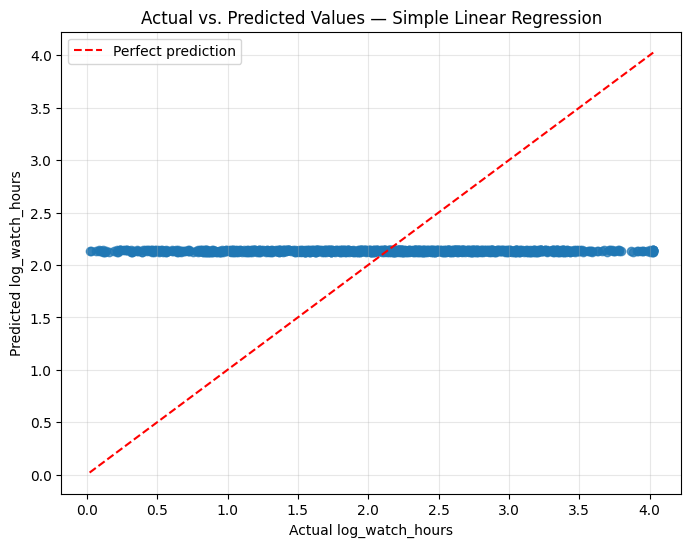


------------------------------
Feature: churned


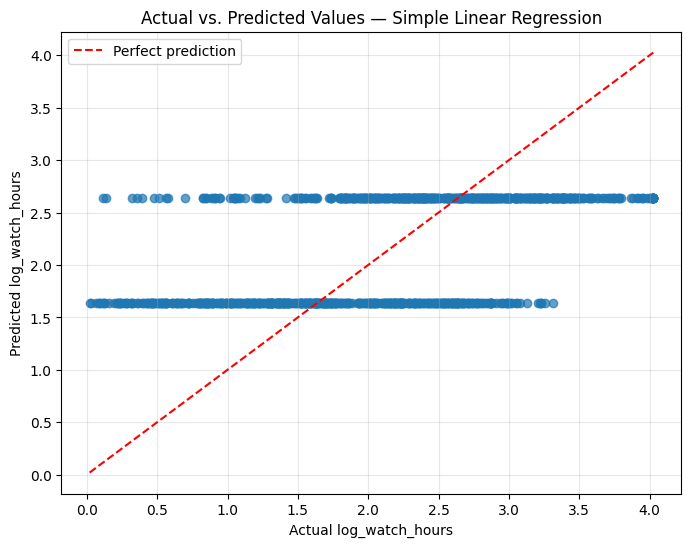


------------------------------
Feature: age


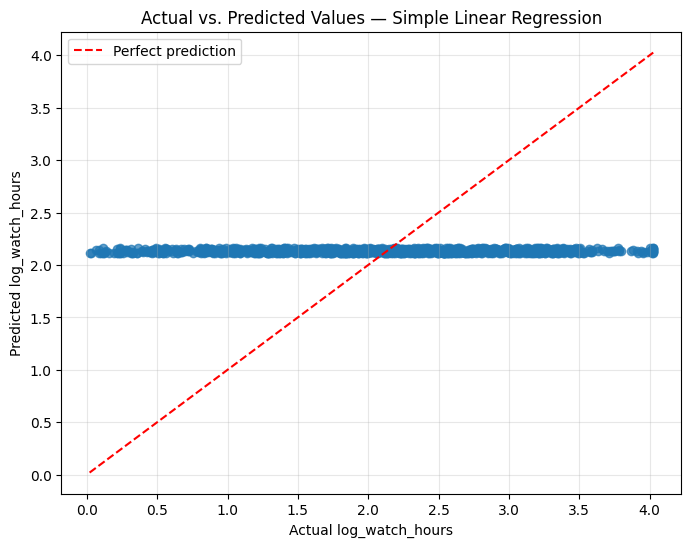


------------------------------
Feature: last_login_days


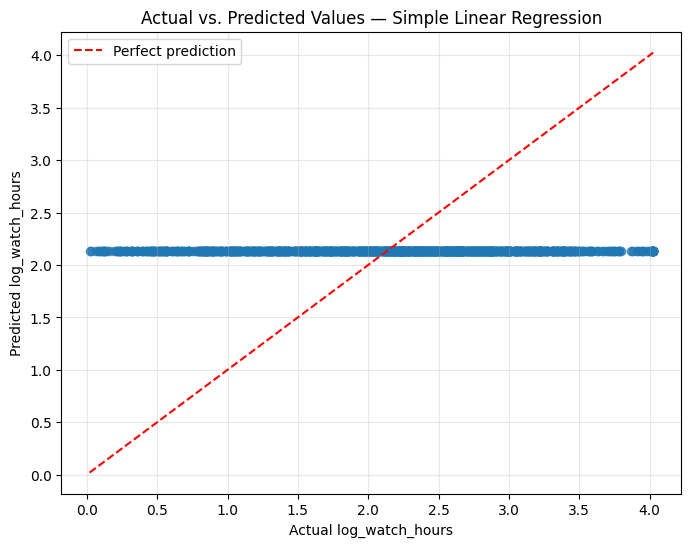


------------------------------
Feature: subscription_type_encoded


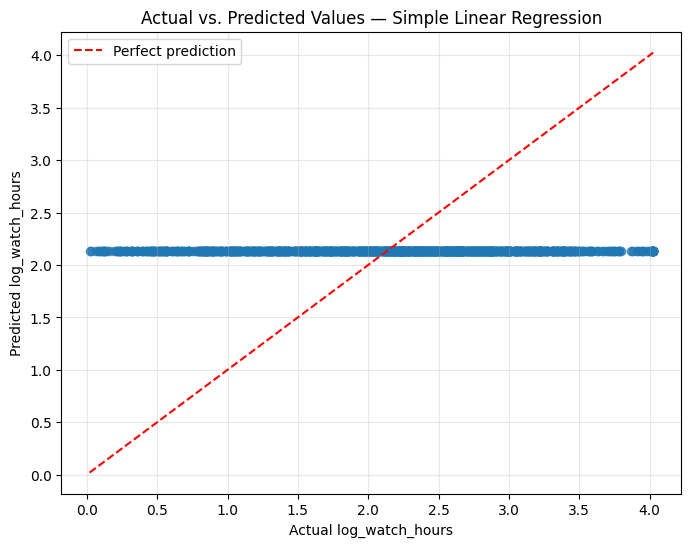

In [ ]:
for number in range(len(linear_regression_features)):
  simple_data = simple_data_packs[number]
  feature = linear_regression_features[number]
  simple_predictions = simple_predictions_packs[number]
  print("\n" + "-"*30)
  print(f"Feature: {feature}")

  plt.figure(figsize=(8, 6))
  plt.scatter(simple_predictions["Actual"], simple_predictions["Predicted"], alpha=0.7)

  min_val = min(simple_predictions["Actual"].min(), simple_predictions["Predicted"].min())
  max_val = max(simple_predictions["Actual"].max(), simple_predictions["Predicted"].max())
  plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", label="Perfect prediction")

  plt.xlabel(f"Actual {predicted_feature}")
  plt.ylabel(f"Predicted {predicted_feature}")
  plt.title("Actual vs. Predicted Values — Simple Linear Regression")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

Predictive performance (model evaluation)

In [ ]:
def calculate_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    nonzero_mask = y_true != 0
    if nonzero_mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

for number in range(len(linear_regression_features)):
  X_train, X_test, y_train, y_test = train_test_tuples[number]
  y_pred = y_pred_packs[number]
  print("\n")
  print("-"*30)
  print(f"Feature: {linear_regression_features[number]}")

  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r_squared = r2_score(y_test, y_pred)
  mape = calculate_mape(y_test, y_pred)

  simple_metrics = pd.DataFrame({
      "Metric": ["MAE", "MSE", "RMSE", "MAPE (%)", "R-squared"],
      "Value": [mae, mse, rmse, mape, r_squared]
  })
  display(simple_metrics)



------------------------------
Feature: number_of_profiles


,Metric,Value
0,MAE,0.753843
1,MSE,0.839925
2,RMSE,0.916474
3,MAPE (%),99.432878
4,R-squared,-0.000100




------------------------------
Feature: churned


,Metric,Value
0,MAE,0.637707
1,MSE,0.609614
2,RMSE,0.780778
3,MAPE (%),80.019671
4,R-squared,0.274133




------------------------------
Feature: age


,Metric,Value
0,MAE,0.753642
1,MSE,0.838831
2,RMSE,0.915877
3,MAPE (%),99.195509
4,R-squared,0.001203




------------------------------
Feature: last_login_days


,Metric,Value
0,MAE,0.753951
1,MSE,0.840114
2,RMSE,0.916577
3,MAPE (%),99.457091
4,R-squared,-0.000324




------------------------------
Feature: subscription_type_encoded


,Metric,Value
0,MAE,0.753911
1,MSE,0.840060
2,RMSE,0.916548
3,MAPE (%),99.451249
4,R-squared,-0.000260


---------------------------------------------------------------

**Multi-Variable Linear Regression**

Prepare the data and display summary statistics

```markdown
Independent Variables (X) : age, last_login_days (base for prediction)

Dependent Variable (Y) : watch_hours (which would be predicted)
```

In [ ]:
numeric_columns = ["number_of_profiles", "churned", "age", "last_login_days", "subscription_type_encoded", predicted_feature]

In [ ]:
multiple_data = df[numeric_columns].copy()

for column in numeric_columns:
    multiple_data[column] = pd.to_numeric(multiple_data[column], errors="coerce")

multiple_data = multiple_data.dropna()
print("Dataset shape:", multiple_data.shape)
display(multiple_data.head())

Dataset shape: (5000, 6)


,number_of_profiles,churned,age,last_login_days,subscription_type_encoded,log_watch_hours
0,1,1,51,29,1,2.755570
1,5,1,47,19,2,0.530628
2,2,0,27,10,2,2.851862
3,2,1,53,12,3,1.706565
4,2,1,56,13,2,1.061257


Correlation matrix and significance testing

,number_of_profiles,churned,age,last_login_days,subscription_type_encoded,log_watch_hours
number_of_profiles,1.000000,-0.158614,0.017333,0.017242,0.022635,-0.010481
churned,-0.158614,1.000000,-0.003515,0.471590,-0.148035,-0.535000
age,0.017333,-0.003515,1.000000,0.016769,-0.013252,0.023871
last_login_days,0.017242,0.471590,0.016769,1.000000,-0.000736,0.004329
subscription_type_encoded,0.022635,-0.148035,-0.013252,-0.000736,1.000000,0.011376
log_watch_hours,-0.010481,-0.535000,0.023871,0.004329,0.011376,1.000000


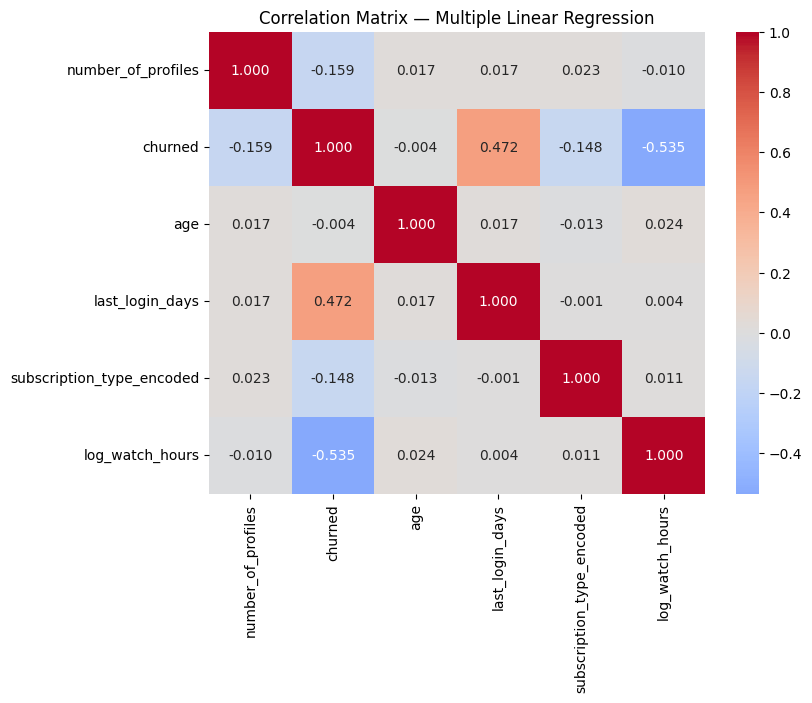


number_of_profiles vs. churned
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = -0.1586, p-value = 0.000000
Result: Significant at alpha=0.05

number_of_profiles vs. age
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = 0.0173, p-value = 0.220432
Result: Not statistically significant

number_of_profiles vs. last_login_days
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = 0.0172, p-value = 0.222847
Result: Not statistically significant

number_of_profiles vs. subscription_type_encoded
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = 0.0226, p-value = 0.109529
Result: Not statistically significant

number_of_profiles vs. log_watch_hours
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = -0.0105, p-value = 0.458717
Result: Not statistically significant

churned vs. age
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = -0.0035, p-value = 0.803742
Result: Not statistically significant

churned vs. last_login_days
H0: ρ = 0 | H1: ρ ≠ 0
Correlation (r) = 0.4716, p-value = 0.000000
Result: Significant at alpha=0.05

churned vs. subscription_type_enc

,Variable 1,Variable 2,Correlation (r),p-value,Significant
0,number_of_profiles,churned,-0.158614,1.566383e-29,Yes
1,number_of_profiles,age,0.017333,2.204316e-01,No
2,number_of_profiles,last_login_days,0.017242,2.228467e-01,No
3,number_of_profiles,subscription_type_encoded,0.022635,1.095290e-01,No
4,number_of_profiles,log_watch_hours,-0.010481,4.587170e-01,No
5,churned,age,-0.003515,8.037425e-01,No
6,churned,last_login_days,0.471590,2.413729e-275,Yes
7,churned,subscription_type_encoded,-0.148035,6.763203e-26,Yes
8,churned,log_watch_hours,-0.535000,0.000000e+00,Yes
9,age,last_login_days,0.016769,2.357945e-01,No


In [ ]:
correlation_matrix = multiple_data.corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Multiple Linear Regression")
plt.show()

correlation_results = []
columns = multiple_data.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        var1 = columns[i]
        var2 = columns[j]
        pair_data = multiple_data[[var1, var2]].dropna()
        r, p_value = stats.pearsonr(pair_data[var1], pair_data[var2])

        print(f"\n{var1} vs. {var2}")
        print("H0: ρ = 0 | H1: ρ ≠ 0")
        print(f"Correlation (r) = {r:.4f}, p-value = {p_value:.6f}")

        if p_value < ALPHA:
            print(f"Result: Significant at alpha={ALPHA}")
        else:
            print("Result: Not statistically significant")

        correlation_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Correlation (r)": r,
            "p-value": p_value,
            "Significant": "Yes" if p_value < ALPHA else "No"
        })

correlation_significance = pd.DataFrame(correlation_results)
display(correlation_significance)

Scatter plots

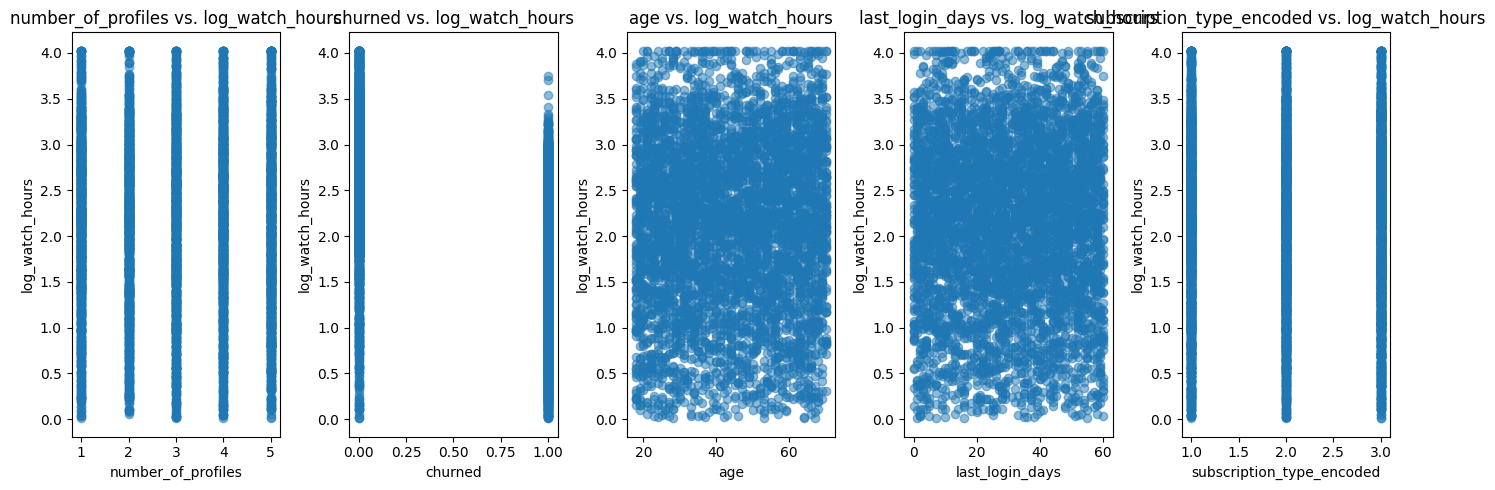

In [ ]:
fig, axes = plt.subplots(1, len(numeric_columns)-1, figsize=(14, 5))

for number in range(len(numeric_columns)-1):

  axes[number].scatter(multiple_data[numeric_columns[number]], multiple_data[numeric_columns[-1]], alpha=0.5)
  axes[number].set_xlabel(f"{numeric_columns[number]}")
  axes[number].set_ylabel(f"{numeric_columns[-1]}")
  axes[number].set_title(f"{numeric_columns[number]} vs. {numeric_columns[-1]}")

plt.tight_layout()
plt.show()

Train-test split and model fitting

In [ ]:
X = multiple_data[numeric_columns[:-1]]
y = multiple_data[numeric_columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

intercept_multiple = multiple_model.intercept_
b_age = multiple_model.coef_[0]
b_login = multiple_model.coef_[1]

print("Multiple Linear Regression Model Coefficients:")
print(f"Intercept = {intercept_multiple:.6f}")
print(f"Age coefficient = {b_age:.6f}")
print(f"Last Login Days coefficient = {b_login:.6f}")
print(f"Equation: watch_hours = {intercept_multiple:.4f} + ({b_age:.6f} × age) + ({b_login:.6f} × last_login_days)")

X_ols_multiple_const = sm.add_constant(X_train)
ols_multiple_model = sm.OLS(y_train, X_ols_multiple_const).fit()
print(ols_multiple_model.summary())

Multiple Linear Regression Model Coefficients:
Intercept = 2.714176
Age coefficient = -0.083491
Last Login Days coefficient = -1.381626
Equation: watch_hours = 2.7142 + (-0.083491 × age) + (-1.381626 × last_login_days)
                            OLS Regression Results                            
Dep. Variable:        log_watch_hours   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     530.1
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:34:08   Log-Likelihood:                -4387.1
No. Observations:                4000   AIC:                             8786.
Df Residuals:                    3994   BIC:                             8824.
Df Model:                           5                                         
Covariance Type:            nonrobust                                 

Testing for significance (t-tests)

In [ ]:
print("t-tests for individual regression coefficients")

for col in numeric_columns[:-1]:
    t_stat = ols_multiple_model.tvalues[col]
    p_val = ols_multiple_model.pvalues[col]
    print(f"\nVariable: {col}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_val:.6f}")
    if p_val < ALPHA:
        print(f"Reject H0: {col} is a statistically significant predictor.")
    else:
        print(f"Do not reject H0: {col} is not a statistically significant predictor.")

t-tests for individual regression coefficients

Variable: number_of_profiles
t-statistic = -10.1174
p-value = 0.000000
Reject H0: number_of_profiles is a statistically significant predictor.

Variable: churned
t-statistic = -51.4630
p-value = 0.000000
Reject H0: churned is a statistically significant predictor.

Variable: age
t-statistic = 0.9026
p-value = 0.366768
Do not reject H0: age is not a statistically significant predictor.

Variable: last_login_days
t-statistic = 25.0651
p-value = 0.000000
Reject H0: last_login_days is a statistically significant predictor.

Variable: subscription_type_encoded
t-statistic = -7.9599
p-value = 0.000000
Reject H0: subscription_type_encoded is a statistically significant predictor.


Testing for significance (F-test)



In [ ]:
print("F-test for the overall regression model")
f_stat_multiple = ols_multiple_model.fvalue
f_p_value_multiple = ols_multiple_model.f_pvalue

print(f"F-statistic = {f_stat_multiple:.4f}")
print(f"p-value = {f_p_value_multiple:.6f}")
print(f"alpha = {ALPHA}")

if f_p_value_multiple < ALPHA:
    print(f"Reject H0: The overall regression model is statistically significant.")
else:
    print(f"Do not reject H0: The overall model is not statistically significant.")

F-test for the overall regression model
F-statistic = 530.1287
p-value = 0.000000
alpha = 0.05
Reject H0: The overall regression model is statistically significant.


Test set predictions

In [ ]:
y_pred_multiple = multiple_model.predict(X_test)
multiple_predictions = X_test.copy()
multiple_predictions["Actual"] = y_test.values
multiple_predictions["Predicted"] = y_pred_multiple
multiple_predictions["Residual"] = multiple_predictions["Actual"] - multiple_predictions["Predicted"]

display(multiple_predictions.head(15))

,number_of_profiles,churned,age,last_login_days,subscription_type_encoded,Actual,Predicted,Residual
1501,5,0,39,22,1,2.394252,2.622958,-0.228706
2586,5,1,18,37,2,0.223144,1.396163,-1.173020
2653,3,0,19,6,2,2.255493,2.364106,-0.108613
1055,1,1,34,51,3,2.673459,1.890960,0.782499
705,1,1,29,59,1,3.226050,2.262459,0.963591
106,2,1,49,46,1,1.360977,1.948562,-0.587585
589,1,1,62,60,2,3.217675,2.190877,1.026798
2468,3,1,25,58,1,1.998774,2.074048,-0.075274
2413,2,0,68,58,2,3.222071,3.455521,-0.233450
1600,5,0,65,25,3,2.446685,2.471788,-0.025102


Actual vs. predicted plot

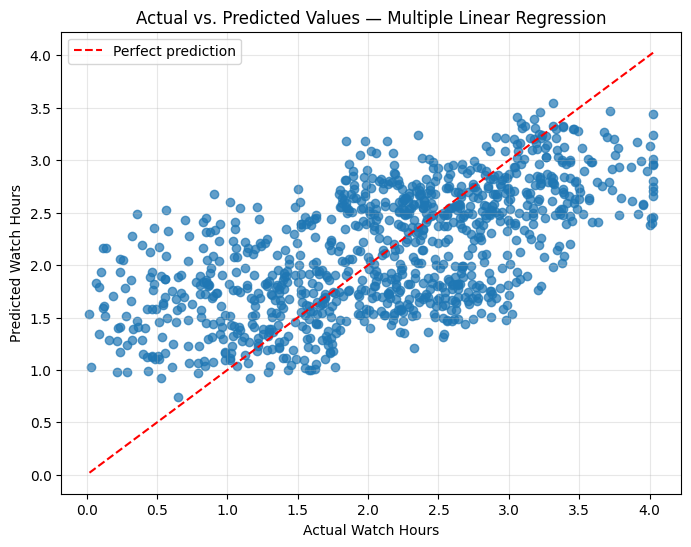

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(multiple_predictions["Actual"], multiple_predictions["Predicted"], alpha=0.7)

min_val = min(multiple_predictions["Actual"].min(), multiple_predictions["Predicted"].min())
max_val = max(multiple_predictions["Actual"].max(), multiple_predictions["Predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", label="Perfect prediction")

plt.xlabel("Actual Watch Hours")
plt.ylabel("Predicted Watch Hours")
plt.title("Actual vs. Predicted Values — Multiple Linear Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Predictive performance (model evaluation)

In [ ]:
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r_squared_multiple = r2_score(y_test, y_pred_multiple)
mape_multiple = calculate_mape(y_test, y_pred_multiple)

multiple_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE (%)", "R-squared"],
    "Value": [mae_multiple, mse_multiple, rmse_multiple, mape_multiple, r_squared_multiple]
})
display(multiple_metrics)

,Metric,Value
0,MAE,0.579880
1,MSE,0.516994
2,RMSE,0.719023
3,MAPE (%),71.784946
4,R-squared,0.384414


---------------------------------------------------------------

**Binary Logistic Regression**

Prepare the data and display summary statistics

```markdown
*Independent Variables (X) : watch_hours, last_login_days, number_of_profiles*

*Dependent Variable (Y) : churned (which would be predicted)*
```

In [ ]:
logistic_columns = [
    # "age",
    "watch_hours",
    "last_login_days",
    "number_of_profiles",
    "churned"
]

predictor_columns = [
    # "age",
    "watch_hours",
    "last_login_days",
    "number_of_profiles"
]

In [ ]:
logistic_data = df[logistic_columns].copy()

for column in predictor_columns:
    logistic_data[column] = pd.to_numeric(logistic_data[column], errors="coerce")

logistic_data["churned"] = pd.to_numeric(logistic_data["churned"], errors="coerce")
logistic_data = logistic_data.dropna()

print("Dataset shape:", logistic_data.shape)
print("\nTarget variable (churned) distribution:")
print(logistic_data["churned"].value_counts())
display(logistic_data.head())

Dataset shape: (5000, 4)

Target variable (churned) distribution:
churned
1    2515
0    2485
Name: count, dtype: int64


,watch_hours,last_login_days,number_of_profiles,churned
0,14.73,29,1,1
1,0.70,19,5,1
2,16.32,10,2,0
3,4.51,12,2,1
4,1.89,13,2,1


Display summary statistics



In [ ]:
print("Summary statistics for predictor variables:")
display(logistic_data[predictor_columns].describe())

print("Target variable proportions:")
target_counts = (
    logistic_data["churned"]
    .value_counts()
    .sort_index()
)

target_proportions = (
    logistic_data["churned"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)


target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_proportions
})
target_summary.index = ["Active (0)", "Churned (1)"]
display(target_summary)

Summary statistics for predictor variables:


,watch_hours,last_login_days,number_of_profiles
count,5000.000000,5000.000000,5000.000000
mean,11.488277,30.089800,3.024400
std,11.226075,17.536078,1.415841
min,0.010000,0.000000,1.000000
25%,3.337500,15.000000,2.000000
50%,8.000000,30.000000,3.000000
75%,16.030000,45.000000,4.000000
max,54.981500,60.000000,5.000000


Target variable proportions:


,Count,Percentage (%)
Active (0),2485,49.7
Churned (1),2515,50.3


Train-test split

In [ ]:
X = logistic_data[predictor_columns]
y = logistic_data["churned"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

Training observations: 4000
Testing observations: 1000

Training target proportions:
churned
1    0.503
0    0.497
Name: proportion, dtype: float64

Testing target proportions:
churned
1    0.503
0    0.497
Name: proportion, dtype: float64


Fit the logistic regression model

In [ ]:
logistic_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logistic_model.fit(X_train, y_train)

y_prob = logistic_model.predict_proba(X_test)[:, 1]
classification_threshold = 0.50
y_pred = (y_prob >= classification_threshold).astype(int)

print("Logistic regression model fitted successfully.")
print(f"Classification threshold = {classification_threshold}")

Logistic regression model fitted successfully.
Classification threshold = 0.5


Logistic regression equation

In [ ]:
logistic_intercept = logistic_model.intercept_[0]
logistic_coefficients = logistic_model.coef_[0]

logistic_coefficients_table = pd.DataFrame({
    "Variable": predictor_columns,
    "Coefficient": logistic_coefficients,
    "Odds_Ratio": np.exp(logistic_coefficients)
})

display(logistic_coefficients_table)
print(f"Intercept = {logistic_intercept:.6f}")

print("\nLogistic regression equation (log-odds scale):")
equation = f"logit(p) = {logistic_intercept:.6f}"
for variable, coefficient in zip(predictor_columns, logistic_coefficients):
    sign = "+" if coefficient >= 0 else "-"
    equation += f" {sign} {abs(coefficient):.6f} × {variable}"
print(equation)

,Variable,Coefficient,Odds_Ratio
0,watch_hours,-0.318425,0.727293
1,last_login_days,0.134713,1.144208
2,number_of_profiles,-0.655524,0.519170


Intercept = 1.172569

Logistic regression equation (log-odds scale):
logit(p) = 1.172569 - 0.318425 × watch_hours + 0.134713 × last_login_days - 0.655524 × number_of_profiles


Predicted probabilities

In [ ]:
logistic_predictions = X_test.copy()
logistic_predictions["Actual_Churn"] = y_test.values
logistic_predictions["Predicted_Probability_Churn"] = y_prob
logistic_predictions["Predicted_Churn_Decision"] = y_pred
logistic_predictions["Predicted_Label"] = logistic_predictions["Predicted_Churn_Decision"].map({0: "Active", 1: "Churned"})

display(logistic_predictions.head(15))

,watch_hours,last_login_days,number_of_profiles,Actual_Churn,Predicted_Probability_Churn,Predicted_Churn_Decision,Predicted_Label
1911,26.05,21,4,0,0.000991,0,Active
3551,2.34,54,4,1,0.993818,1,Churned
1241,6.06,30,4,0,0.659752,1,Churned
3182,9.44,46,2,1,0.954884,1,Churned
3678,0.10,20,1,1,0.960054,1,Churned
1873,1.59,29,3,1,0.931270,1,Churned
2831,6.23,49,3,1,0.978608,1,Churned
1362,2.46,53,1,1,0.998966,1,Churned
1385,4.33,25,4,0,0.631697,1,Churned
2016,9.54,60,5,0,0.949785,1,Churned


Classification metrics

In [ ]:
# Calculate classification metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

classification_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

display(classification_metrics)

,Metric,Value
0,Accuracy,0.867000
1,Precision,0.854406
2,Recall,0.886680
3,F1-score,0.870244
4,ROC-AUC,0.940846


Confusion matrix

Confusion matrix:
[[421  76]
 [ 57 446]]


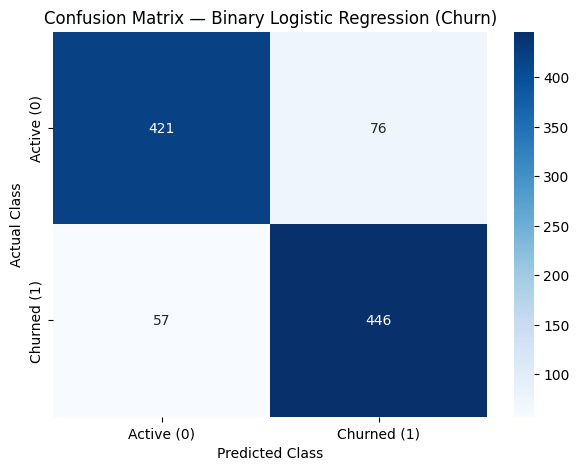

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion matrix:")
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Active (0)", "Churned (1)"], yticklabels=["Active (0)", "Churned (1)"])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — Binary Logistic Regression (Churn)")
plt.show()

Classification report

In [ ]:
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"], zero_division=0))

Classification report:
              precision    recall  f1-score   support

      Active       0.88      0.85      0.86       497
     Churned       0.85      0.89      0.87       503

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



ROC curve and AUC

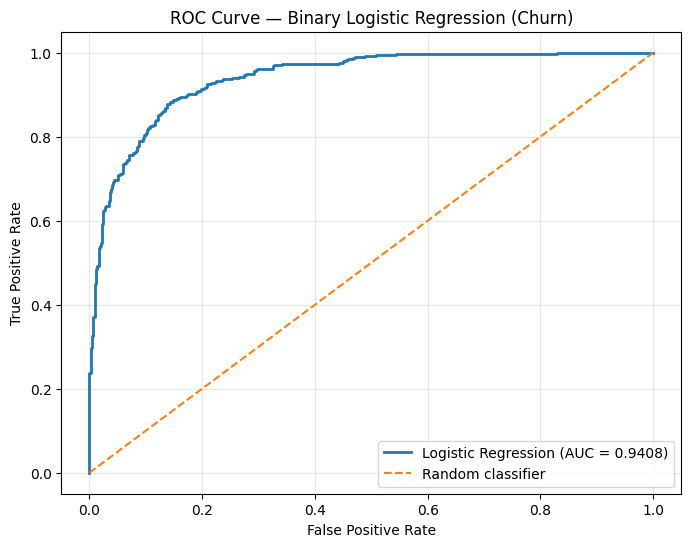

ROC-AUC = 0.9408


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Binary Logistic Regression (Churn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

User-defined prediction

In [ ]:
# Predict churn for a hypothetical Netflix subscriber
new_subscriber = pd.DataFrame({
    # "age": [35],
    "watch_hours": [30.0],
    "last_login_days": [100],
    "number_of_profiles": [5]
})

probabilities = logistic_model.predict_proba(new_subscriber)[0]
prob_active = probabilities[0]
prob_churn = probabilities[1]

prediction_binary = logistic_model.predict(new_subscriber)[0]
prediction = "Churned" if prediction_binary == 1 else "Active"

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION CHURN PREDICTION")
print("=" * 50)

print("\nInput subscriber details:")
display(new_subscriber)

print(f"\nProbability of remaining Active: {prob_active:.4f} ({prob_active * 100:.2f}%)")
print(f"Probability of Churning:         {prob_churn:.4f} ({prob_churn * 100:.2f}%)")
print(f"\nPredicted Subscriber State:      {prediction}")


LOGISTIC REGRESSION CHURN PREDICTION

Input subscriber details:


,watch_hours,last_login_days,number_of_profiles
0,30.0,100,5



Probability of remaining Active: 0.1402 (14.02%)
Probability of Churning:         0.8598 (85.98%)

Predicted Subscriber State:      Churned


#TASK 4
**Supervised machine learning with decision trees**

Define Constants

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

Data Preparation

In [ ]:
#useless for the model
columns_to_drop = [
    "churned",
    "customer_id",
    "log_watch_hours",
    "subscription_type_encoded"
]

#errors="ignore" makes the code safe even if a column is already missing
X = df.drop(columns=columns_to_drop, errors="ignore")
y = df["churned"]

# Convert categorical features to numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, dtype=int)

print("Data prepared for Decision Tree modeling.")
print(f"Shape of features after encoding: {X_encoded.shape}")
print(f"Shape of target variable:         {y.shape}")

print(f"\nFeatures used ({X_encoded.shape[1]} total):")
print(X_encoded.columns.tolist())
print(f"\nTarget distribution (churned):")
print(y.value_counts())
print(f"\nClass balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Data prepared for Decision Tree modeling.
Shape of features after encoding: (5000, 33)
Shape of target variable:         (5000,)

Features used (33 total):
['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'gender_female', 'gender_male', 'gender_other', 'subscription_type_basic', 'subscription_type_premium', 'subscription_type_standard', 'region_africa', 'region_asia', 'region_europe', 'region_north america', 'region_oceania', 'region_south america', 'device_desktop', 'device_laptop', 'device_mobile', 'device_tablet', 'device_tv', 'payment_method_credit card', 'payment_method_crypto', 'payment_method_debit card', 'payment_method_gift card', 'payment_method_paypal', 'favorite_genre_action', 'favorite_genre_comedy', 'favorite_genre_documentary', 'favorite_genre_drama', 'favorite_genre_horror', 'favorite_genre_romance', 'favorite_genre_sci-fi']

Target distribution (churned):
churned
1    2515
0    2485
Name: count, dtype: int64

Class balance (%):
churned
1    50.3
0    49.

Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training instances: {len(x_train)}")
print(f"Testing instances: {len(x_test)}")

#target proportion check to confirm stratification worked
print(f"\nTraining target proportions:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nTesting target proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training instances: 4000
Testing instances: 1000

Training target proportions:
churned
1    0.503
0    0.497
Name: proportion, dtype: float64

Testing target proportions:
churned
1    0.503
0    0.497
Name: proportion, dtype: float64


Base Decision Tree Classifier

In [ ]:
# Initialize and fit Decision Tree Classifier
classifier = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None, min_samples_leaf=1)
classifier.fit(x_train, y_train)

# Evaluation on test set
y_pred = classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the baseline Decision Tree classifier: {accuracy * 100:.2f}%')

#tree structure info to highlight overfitting.
print(f"\nTree depth:        {classifier.get_depth()}")
print(f"Number of leaves:  {classifier.get_n_leaves()}")

Accuracy of the baseline Decision Tree classifier: 98.10%

Tree depth:        11
Number of leaves:  100


Analysis of Tree Depths

,Max Depth,Train Accuracy,Test Accuracy,Balanced Accuracy,Macro F1
0,2,0.8238,0.831,0.8302,0.8278
1,3,0.9045,0.908,0.9077,0.9077
2,4,0.9045,0.908,0.9077,0.9077
3,5,0.9388,0.929,0.9292,0.9289
4,6,0.9675,0.962,0.9622,0.9620
5,7,0.9908,0.983,0.9830,0.9830
6,8,0.9945,0.982,0.9820,0.9820
7,9,0.9990,0.980,0.9800,0.9800
8,10,0.9995,0.980,0.9800,0.9800
9,11,1.0000,0.981,0.9810,0.9810


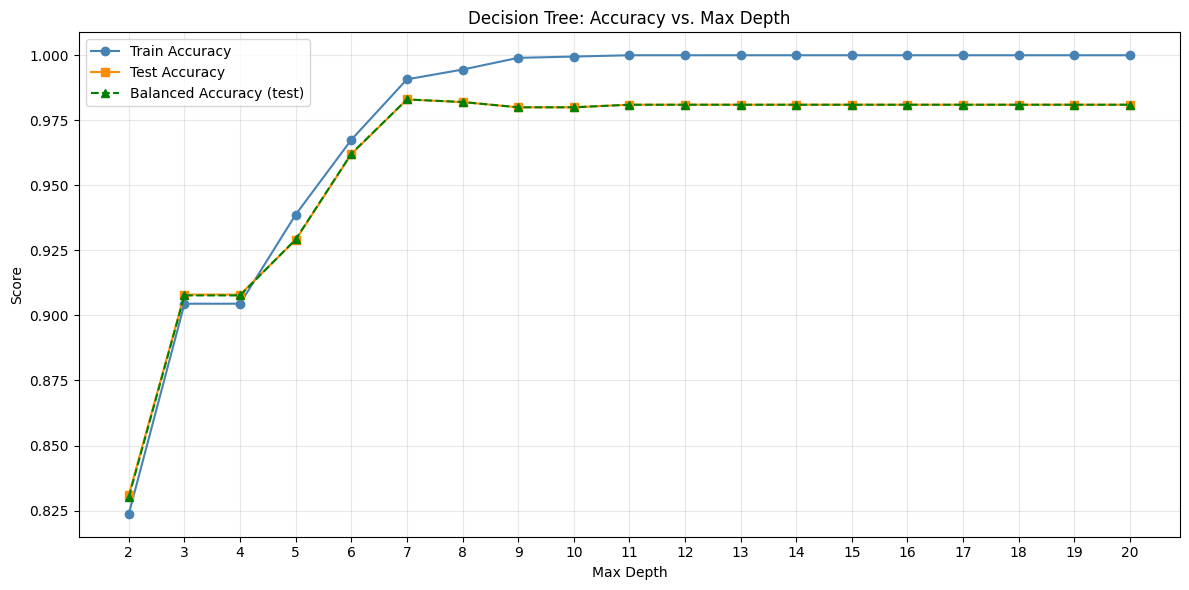

In [ ]:
depths = list(range(2, 21))
depth_results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(x_train, y_train)

    train_pred = dt.predict(x_train)
    test_pred = dt.predict(x_test)

    depth_results.append({
        "Max Depth": depth,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "Macro F1": f1_score(y_test, test_pred, average='macro', zero_division=0)
    })

depth_df = pd.DataFrame(depth_results)
display(depth_df.round(4))

# Plotting accuracy curves
plt.figure(figsize=(12, 6))
plt.plot(depth_df["Max Depth"], depth_df["Train Accuracy"],
         label="Train Accuracy", marker='o', color="steelblue")
plt.plot(depth_df["Max Depth"], depth_df["Test Accuracy"],
         label="Test Accuracy", marker='s', color="darkorange")
# CHANGE: added Balanced Accuracy line.
plt.plot(depth_df["Max Depth"], depth_df["Balanced Accuracy"],
         label="Balanced Accuracy (test)", marker='^', color="green", linestyle="--")
plt.title("Decision Tree: Accuracy vs. Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Analysis of Minimum Samples per Leaf


,Min Samples Leaf,Train Accuracy,Test Accuracy,Balanced Accuracy,Macro F1
0,1,1.0000,0.981,0.9810,0.9810
1,2,0.9938,0.984,0.9841,0.9840
2,5,0.9870,0.980,0.9800,0.9800
3,10,0.9808,0.979,0.9791,0.9790
4,15,0.9770,0.975,0.9750,0.9750
5,20,0.9720,0.967,0.9670,0.9670
6,30,0.9652,0.947,0.9470,0.9470
7,50,0.9592,0.949,0.9491,0.9490
8,100,0.9140,0.909,0.9093,0.9088


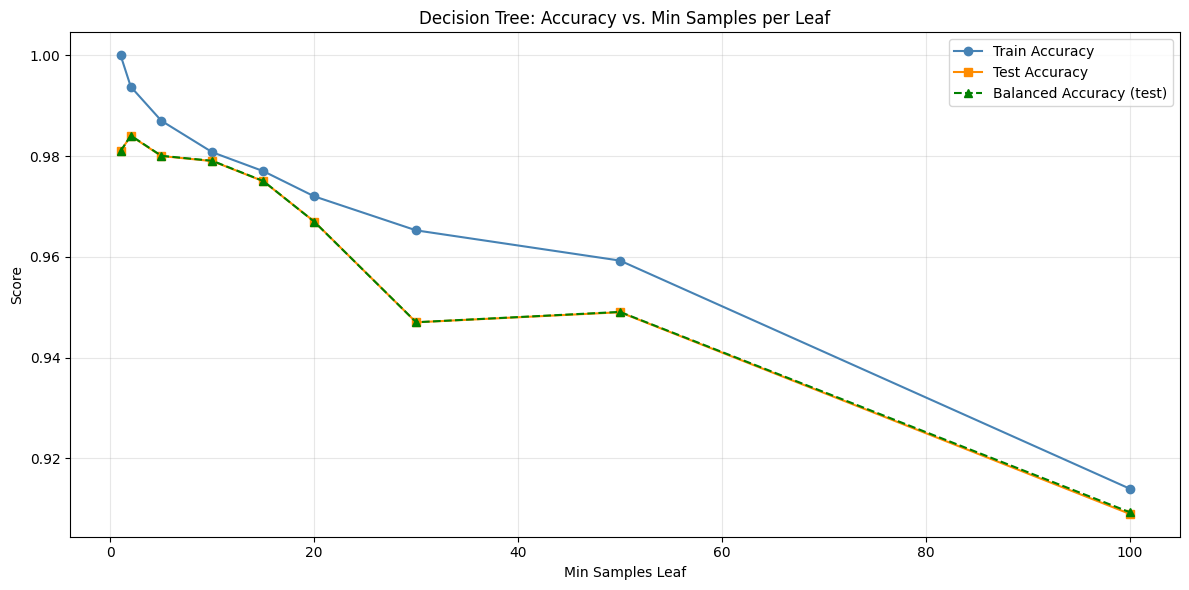

In [ ]:
min_samples_list = [1, 2, 5, 10, 15, 20, 30, 50, 100]
leaf_results = []

for msl in min_samples_list:
    dt = DecisionTreeClassifier(min_samples_leaf=msl, random_state=RANDOM_STATE)
    dt.fit(x_train, y_train)

    train_pred = dt.predict(x_train)
    test_pred = dt.predict(x_test)

    leaf_results.append({
        "Min Samples Leaf": msl,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "Macro F1": f1_score(y_test, test_pred, average='macro', zero_division=0)
    })

leaf_df = pd.DataFrame(leaf_results)
display(leaf_df.round(4))

# Plotting accuracy curves
plt.figure(figsize=(12, 6))
plt.plot(leaf_df["Min Samples Leaf"], leaf_df["Train Accuracy"],
         label="Train Accuracy", marker='o', color="steelblue")
plt.plot(leaf_df["Min Samples Leaf"], leaf_df["Test Accuracy"],
         label="Test Accuracy", marker='s', color="darkorange")
plt.plot(leaf_df["Min Samples Leaf"], leaf_df["Balanced Accuracy"],
         label="Balanced Accuracy (test)", marker='^', color="green", linestyle="--")
plt.title("Decision Tree: Accuracy vs. Min Samples per Leaf")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Decision Tree vs. Decision Rule Classifier

In [ ]:
def evaluate_cross_validation(clf, X_data, y_data, cv_splits=10):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

    acc_scores, bal_acc_scores, prec_scores, rec_scores, f1_scores, gmean_scores = [], [], [], [], [], []

    for train_index, test_index in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_index], X_data.iloc[test_index]
        y_tr, y_te = y_data.iloc[train_index], y_data.iloc[test_index]

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        acc_scores.append(accuracy_score(y_te, y_pred))
        bal_acc_scores.append(balanced_accuracy_score(y_te, y_pred))
        prec_scores.append(precision_score(y_te, y_pred, average='macro', zero_division=0))
        rec_scores.append(recall_score(y_te, y_pred, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
        gmean_scores.append(geometric_mean_score(y_te, y_pred, average='macro'))

    results = pd.DataFrame({
        "Accuracy": acc_scores,
        "Balanced Accuracy": bal_acc_scores,
        "Precision": prec_scores,
        "Recall": rec_scores,
        "F1 Score": f1_scores,
        "G-Mean": gmean_scores
    })
    results.index = [f"Fold {i+1}" for i in range(cv_splits)]
    results.loc["Average"] = results.mean(numeric_only=True)
    return results


# 1. Decision Tree Evaluation
# min_samples_leaf - 5 (based on tuning above).
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE)
dt_results = evaluate_cross_validation(dt_model, X_encoded, y)
print("=== Complex Decision Tree (max_depth=10, min_samples_leaf=5) ===")
print("=== Stratified 10-Fold Cross-Validation Results ===")
display(dt_results.round(4))

# 2. Rule-Based Classifier Evaluation
rule_model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
rule_results = evaluate_cross_validation(rule_model, X_encoded, y)
print("\n=== Rule-Based Decision Tree (max_depth=3) ===")
print("=== Stratified 10-Fold Cross-Validation Results ===")
display(rule_results.round(4))

=== Complex Decision Tree (max_depth=10, min_samples_leaf=5) ===
=== Stratified 10-Fold Cross-Validation Results ===


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,G-Mean
Fold 1,0.9900,0.9901,0.9901,0.9901,0.9900,0.9901
Fold 2,0.9820,0.9820,0.9820,0.9820,0.9820,0.9820
Fold 3,0.9840,0.9841,0.9841,0.9841,0.9840,0.9841
Fold 4,0.9900,0.9900,0.9900,0.9900,0.9900,0.9900
Fold 5,0.9720,0.9720,0.9721,0.9720,0.9720,0.9720
Fold 6,0.9820,0.9820,0.9820,0.9820,0.9820,0.9820
Fold 7,0.9880,0.9880,0.9882,0.9880,0.9880,0.9880
Fold 8,0.9780,0.9780,0.9781,0.9780,0.9780,0.9780
Fold 9,0.9640,0.9640,0.9641,0.9640,0.9640,0.9640
Fold 10,0.9620,0.9620,0.9622,0.9620,0.9620,0.9620



=== Rule-Based Decision Tree (max_depth=3) ===
=== Stratified 10-Fold Cross-Validation Results ===


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,G-Mean
Fold 1,0.9060,0.9055,0.9127,0.9055,0.9055,0.9055
Fold 2,0.9000,0.8997,0.9023,0.8997,0.8998,0.8997
Fold 3,0.9120,0.9117,0.9149,0.9117,0.9118,0.9117
Fold 4,0.9160,0.9155,0.9224,0.9155,0.9156,0.9155
Fold 5,0.9140,0.9135,0.9208,0.9135,0.9136,0.9135
Fold 6,0.9060,0.9059,0.9080,0.9059,0.9059,0.9059
Fold 7,0.9260,0.9258,0.9312,0.9258,0.9258,0.9258
Fold 8,0.8960,0.8958,0.9012,0.8958,0.8956,0.8958
Fold 9,0.8980,0.8979,0.8995,0.8979,0.8979,0.8979
Fold 10,0.8620,0.8618,0.8657,0.8618,0.8616,0.8618


Extracted IF-THEN Rules from the Rule-Based Classifier

Extracted Decision Rules (max_depth=3)
 
|--- watch_hours <= 4.98
|   |--- last_login_days <= 6.50
|   |   |--- subscription_type_basic <= 0.50
|   |   |   |--- class: 0
|   |   |--- subscription_type_basic >  0.50
|   |   |   |--- class: 1
|   |--- last_login_days >  6.50
|   |   |--- number_of_profiles <= 3.50
|   |   |   |--- class: 1
|   |   |--- number_of_profiles >  3.50
|   |   |   |--- class: 1
|--- watch_hours >  4.98
|   |--- last_login_days <= 30.50
|   |   |--- subscription_type_basic <= 0.50
|   |   |   |--- class: 0
|   |   |--- subscription_type_basic >  0.50
|   |   |   |--- class: 0
|   |--- last_login_days >  30.50
|   |   |--- watch_hours <= 20.01
|   |   |   |--- class: 1
|   |   |--- watch_hours >  20.01
|   |   |   |--- class: 0



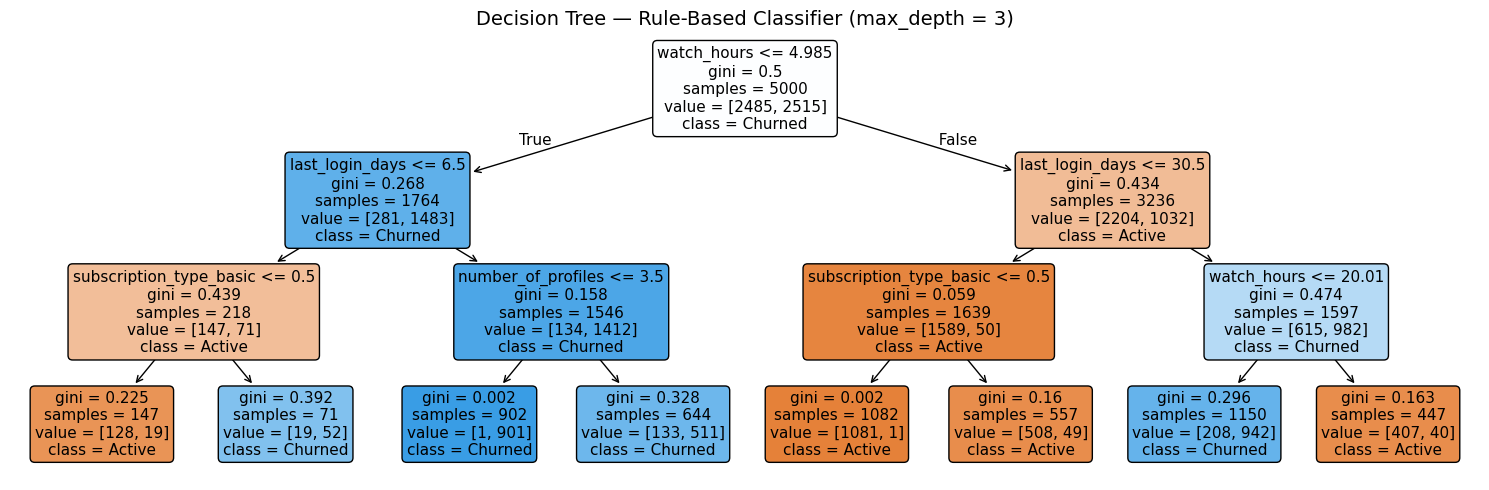

In [ ]:
from sklearn.tree import plot_tree

rule_model.fit(X_encoded, y)
rules = export_text(rule_model, feature_names=list(X_encoded.columns))
print("Extracted Decision Rules (max_depth=3)")
print(" ")
print(rules)

plt.figure(figsize=(15, 5))

plot_tree(
    rule_model,
    feature_names=list(X_encoded.columns),
    class_names=["Active", "Churned"],
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=True,
    proportion=False
)

plt.title("Decision Tree — Rule-Based Classifier (max_depth = 3)", fontsize=14)
plt.tight_layout()
plt.show()

#TASK 5

Unsupervised learning

Data Selection

In [ ]:

# COPY of the ORIGINAL dataset here ('df_netflix'), because the main 'df'
#has 'customer_id' removed.

try:
    df_netflix = pd.read_csv("netflix_customer_churn.csv")
    print("Original dataset loaded successfully for clustering.")
    print(f"Shape: {df_netflix.shape}")
except FileNotFoundError:
    raise FileNotFoundError(
        "The file 'netflix_customer_churn.csv' was not found. "
        "Please upload the original dataset to the Colab environment."
    )

# Select numerical variables for clustering
clustering_features = [
    "age",
    "watch_hours",
    "last_login_days"
]

# Clean from missing values
data_for_clustering = df_netflix[clustering_features].copy().dropna()

# align df_netflix with the cleaned data so indices match.
# This is crucial: kmedoids.medoid_indices_ returns indices into the cleaned data.
df_netflix = df_netflix.loc[data_for_clustering.index].reset_index(drop=True)
data_for_clustering = data_for_clustering.reset_index(drop=True)

print("\nNumber of observations to cluster:", len(data_for_clustering))
print(data_for_clustering.head())

# Create feature matrix
X_clustering = data_for_clustering[clustering_features].copy()

# Standardize variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print("\nMean after standardization (should be close to 0):\n", X_scaled.mean(axis=0).round(4))
print("\nStandard deviation after standardization (should be 1):\n", X_scaled.std(axis=0))

Original dataset loaded successfully for clustering.
Shape: (5000, 14)

Number of observations to cluster: 5000
   age  watch_hours  last_login_days
0   51        14.73               29
1   47         0.70               19
2   27        16.32               10
3   53         4.51               12
4   56         1.89               13

Mean after standardization (should be close to 0):
 [-0.  0. -0.]

Standard deviation after standardization (should be 1):
 [1. 1. 1.]


**K-Means**

INIT K-Means

In [ ]:
inertias = []
silhouette_scores = []

K_values = range(2, 11)


for k in K_values:

    # Create and fit the K-means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    # Store the within-cluster sum of squares
    inertias.append(kmeans.inertia_)

    # Store the silhouette score
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

diagnostics_df = pd.DataFrame({
    "K": list(K_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})
print("K-Means diagnostics:")
display(diagnostics_df.round(4))

K-Means diagnostics:


,K,Inertia,Silhouette Score
0,2,11182.6923,0.2695
1,3,8612.3563,0.2867
2,4,6536.5814,0.2979
3,5,5194.8486,0.3078
4,6,4687.3838,0.3086
5,7,4245.9347,0.3071
6,8,3895.3908,0.3035
7,9,3607.0424,0.2794
8,10,3348.2283,0.2798


Elbow-plot

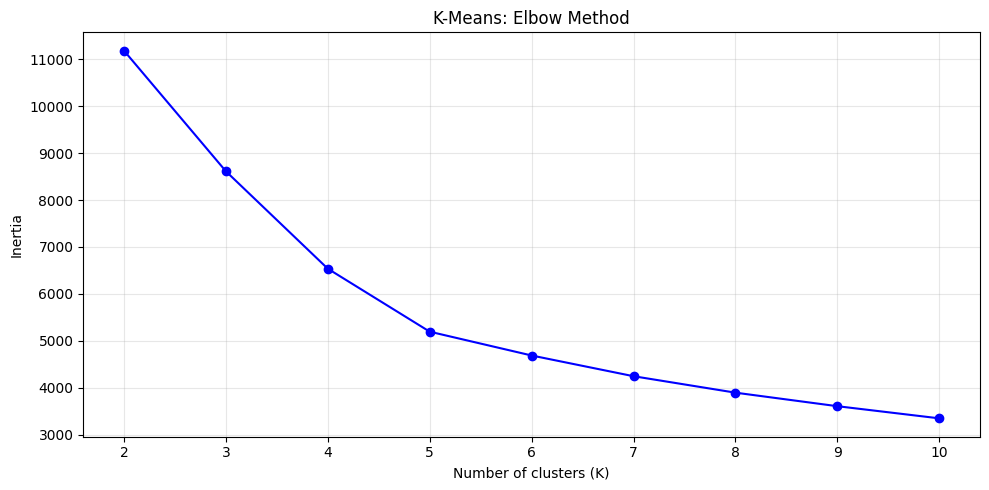

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(K_values, inertias, marker="o", color="blue")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means: Elbow Method")
plt.xticks(list(K_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Silhoutte score

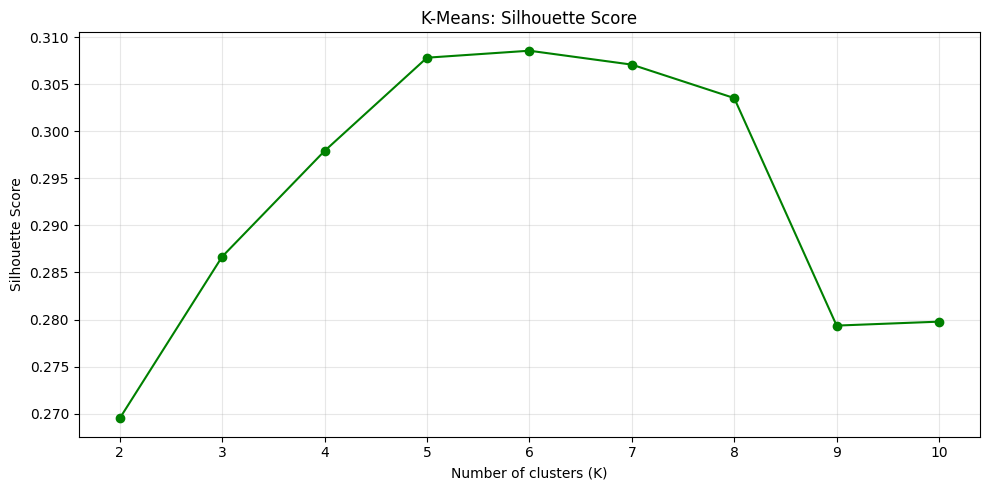

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(K_values, silhouette_scores, marker="o", color="green")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means: Silhouette Score")
plt.xticks(list(K_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation of silhouette scores:
# close to  1 -> well-separated clusters
# around    0 -> overlapping clusters
# negative    -> observations may be assigned to the wrong clusters

Fit the final K-Means model

In [ ]:
# Fit final K-Means model with K=3 on Netflix data
K_FINAL = 5

kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=20
)

# Assign cluster labels to the Netflix DataFrame
df_netflix["kmeans_cluster"] = kmeans.fit_predict(X_scaled)
print(f"K-Means cluster label counts (K={K_FINAL}):")
print(df_netflix["kmeans_cluster"].value_counts().sort_index())

K-Means cluster label counts (K=5):
kmeans_cluster
0    1129
1    1154
2     444
3    1139
4    1134
Name: count, dtype: int64


Visualize the clusters

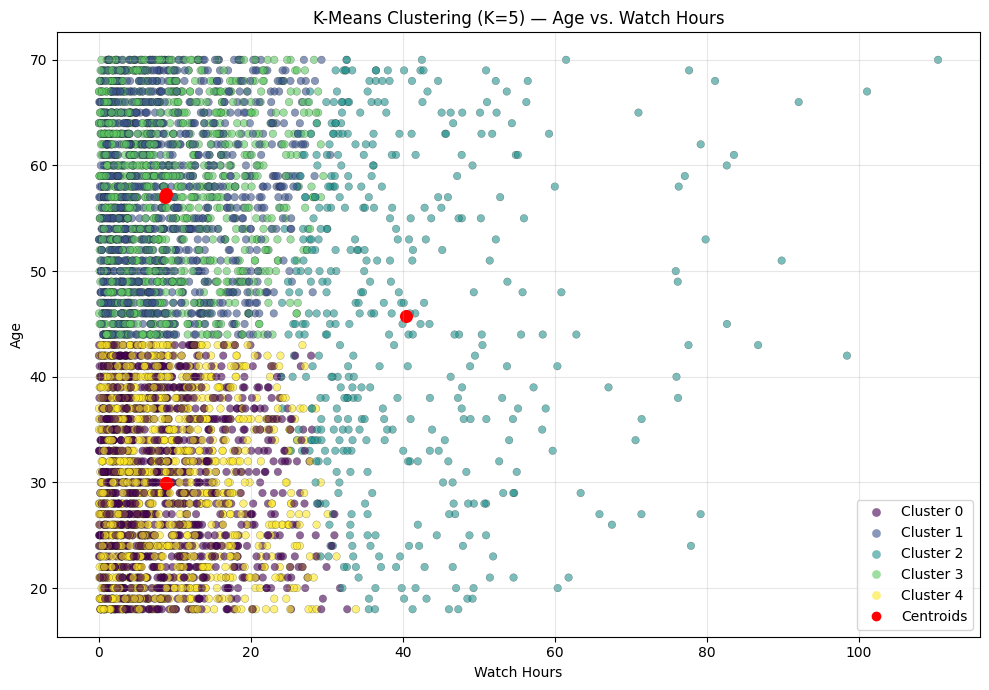

In [ ]:
# Visualize K-Means clusters for Netflix Users (Age vs Watch Hours)
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_netflix["watch_hours"],
    df_netflix["age"],
    c=df_netflix["kmeans_cluster"],
    cmap="viridis",
    s=30,
    alpha=0.6,
    edgecolor="k",
    linewidth=0.2
)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_original[:, 1],  # watch_hours
    centroids_original[:, 0],  # age
    c="red",
    s=250,
    marker=".",
    linewidth=1.5,
    label="Centroids"
)

plt.xlabel("Watch Hours")
plt.ylabel("Age")
plt.title(f"K-Means Clustering (K={K_FINAL}) — Age vs. Watch Hours")
plt.grid(True, alpha=0.3)

plt.legend(
    handles=scatter.legend_elements()[0] + [
        plt.Line2D([], [], marker='.', color='red', linestyle='None',
                   markersize=12, label='Centroids')
    ],
    labels=[f"Cluster {i}" for i in range(K_FINAL)] + ["Centroids"]
)

plt.tight_layout()
plt.show()

Examine the cluster centers

In [ ]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers_original,
    columns=clustering_features
)
centers_df.index.name = "Cluster"

print("K-Means Cluster Centroids (typical customer profiles):")
display(centers_df.round(2))

K-Means Cluster Centroids (typical customer profiles):


,age,watch_hours,last_login_days
Cluster,,,
0,29.99,8.88,45.02
1,57.05,8.75,45.66
2,45.77,40.41,30.64
3,57.30,8.84,14.93
4,29.93,8.90,14.40


-------------------------------------------------------

**K-Medoid**

Fit K-Medoids

In [ ]:
kmedoids = KMedoids(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    metric="euclidean"
)

df_netflix["kmedoids_cluster"] = kmedoids.fit_predict(X_scaled)
print(f"K-Medoids cluster label counts (K={K_FINAL}):")
print(df_netflix["kmedoids_cluster"].value_counts().sort_index())

K-Medoids cluster label counts (K=5):
kmedoids_cluster
0     634
1    1144
2    1074
3    1092
4    1056
Name: count, dtype: int64


Visualize the clusters

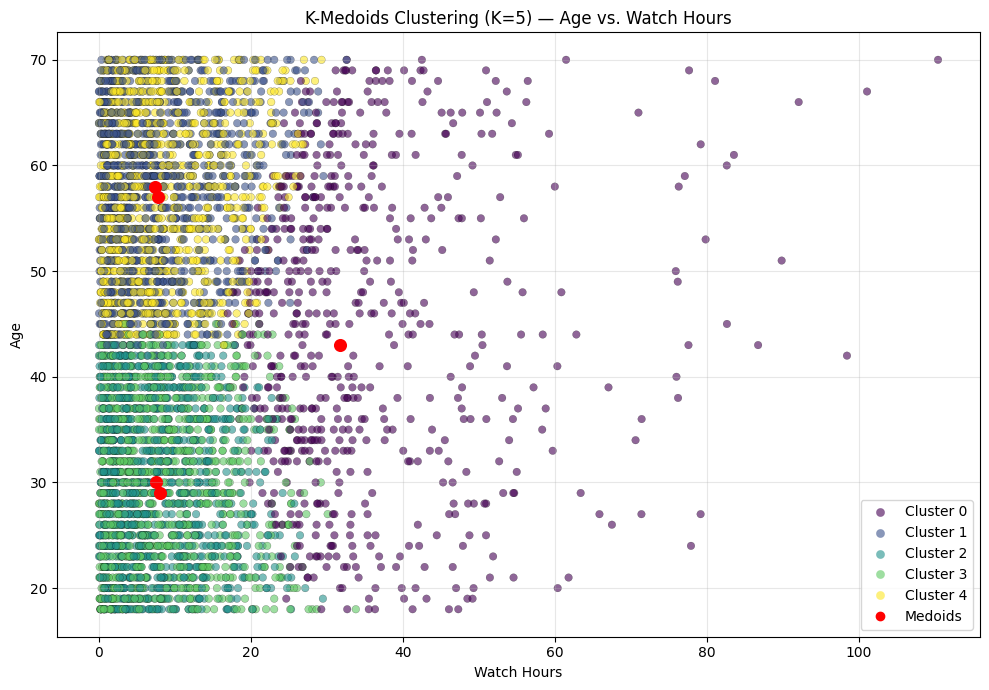

In [ ]:
# Visualize K-Medoids clusters
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_netflix["watch_hours"],
    df_netflix["age"],
    c=df_netflix["kmedoids_cluster"],
    cmap="viridis",
    s=30,
    alpha=0.6,
    edgecolor="k",
    linewidth=0.2
)

medoid_indices = kmedoids.medoid_indices_
medoids_original = data_for_clustering.iloc[medoid_indices]

plt.scatter(
    medoids_original["watch_hours"],
    medoids_original["age"],
    c="red",
    s=250,
    marker=".",
    linewidth=1.5,
    label="Medoids"
)

plt.xlabel("Watch Hours")
plt.ylabel("Age")
plt.title(f"K-Medoids Clustering (K={K_FINAL}) — Age vs. Watch Hours")
plt.grid(True, alpha=0.3)

plt.legend(
    handles=scatter.legend_elements()[0] + [
        plt.Line2D([], [], marker='.', color='red', linestyle='None',
                   markersize=12, label='Medoids')
    ],
    labels=[f"Cluster {i}" for i in range(K_FINAL)] + ["Medoids"]
)

plt.tight_layout()
plt.show()

Identify selected variables as medoids

In [ ]:
# Identify actual user profiles acting as medoids
medoid_indices = kmedoids.medoid_indices_

medoid_df = df_netflix.iloc[medoid_indices][
    ["customer_id"] + clustering_features + ["kmedoids_cluster"]
].copy()

medoid_df = medoid_df.rename(columns={"kmedoids_cluster": "assigned_cluster"})
medoid_df = medoid_df.set_index("assigned_cluster").sort_index()

print("Representative real customers (medoids) chosen from the database:")
display(medoid_df)

Representative real customers (medoids) chosen from the database:


,customer_id,age,watch_hours,last_login_days
assigned_cluster,,,,
0,d04d1f2d-ed98-4ffe-b4f8-05678d9903a2,43,31.73,34
1,b15d15eb-0dda-409b-90c8-211757521f5d,58,7.36,18
2,a22b2cef-2032-47d9-8fb4-36f3dcf93b94,30,7.51,45
3,e42d9b7c-45aa-407a-8bd8-5e0622a2ecbf,29,8.06,13
4,c5922e16-8d07-4107-bf11-7a7d14353f44,57,7.79,46


**Compare the results**

Select comparison data

In [ ]:
# Create cluster comparison dataframe for first 20 records (K-Means vs K-Medoids only)
comparison = df_netflix[
    [
        "customer_id",
        "kmeans_cluster",
        "kmedoids_cluster"
    ]
].copy()

display(comparison.head(20))

,customer_id,kmeans_cluster,kmedoids_cluster
0,a9b75100-82a8-427a-a208-72f24052884a,3,1
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,3,1
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,4,3
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,3,1
4,4e265c34-103a-4dbb-9553-76c9aa47e946,3,1
5,d8079475-5be7-47e9-8782-ceb7ff61395e,3,1
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,3,1
7,02387681-8c42-462a-807a-de0168c73b38,1,4
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,3,1
9,eae6439e-8cdf-4258-ab49-c493925b927a,0,2


Count observations in each cluster

In [ ]:
# Display observations per cluster across models
print("Cluster sizes for Netflix customer database:")

sizes_df = pd.DataFrame({
    "K-Means": df_netflix["kmeans_cluster"].value_counts().sort_index(),
    "K-Medoids": df_netflix["kmedoids_cluster"].value_counts().sort_index()
})
sizes_df.index.name = "Cluster"
display(sizes_df)

Cluster sizes for Netflix customer database:


,K-Means,K-Medoids
Cluster,,
0,1129,634
1,1154,1144
2,444,1074
3,1139,1092
4,1134,1056


Silhouette scores

In [ ]:
# Calculate silhouette scores for K-means and K-medoids

methods = {
     "K-means": df_netflix["kmeans_cluster"],
    "K-medoids": df_netflix["kmedoids_cluster"]
}
print("Silhouette scores comparison:\n")
for name, labels in methods.items():

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"{name}: {score:.3f}")

Silhouette scores comparison:

K-means: 0.308
K-medoids: 0.302
